In [ ]:
import pandas as pd

In [ ]:
original_narratvives_df = pd.read_csv('Catherine_man.csv')
entity_classifications_df = pd.read_csv('Entity_Topic_Classifications_Catherine_man.csv')

In [ ]:
original_narratvives_df

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id
0,monetary policy,short-circuit the inflationary expectations dy...,Monetary policy tools are used to influence in...,The challenge is to deploy monetary policy too...,NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_0
1,monetary policy,moderate the hit to purchasing power,Monetary policy tools are used to influence in...,The challenge is to deploy monetary policy too...,NaN,NaN,NaN,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_1
2,current inflation,affecting future price inflation,Current inflation influences price expectation...,Uncertainties about price expectations and pri...,NaN,NaN,NaN,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_2
3,price realisations,evolution of real income and demand,Price realisations affect real income and dema...,"Relatedly, but its own source of uncertainty i...",NaN,NaN,medium-term,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_3
4,monetary policy,influence inflation and output,Monetary policy affects inflation and output t...,"Another uncertainty, particularly important fo...",NaN,NaN,medium term,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_4
...,...,...,...,...,...,...,...,...,...,...,...,...
303,contractionary monetary policy shock,output declines,Tightening monetary policy reduces economic ac...,"After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_54
304,output decline,reduction in the demand for emissions,"Lower output reduces industrial activity, decr...","After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_55
305,output decline under ETS,carbon price falls,Reduced demand for emissions under an ETS lead...,Under an ETS the carbon price falls (while und...,NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_56
306,fall in carbon price under ETS,boosts output in foreign country,"Lower carbon prices make polluting cheaper, en...","In the foreign country, the fall in price unde...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_57


In [ ]:
entity_classifications_df

,entity,topic,classification,document_reference,custom_id,speech_id,request_idx,speech_narrative_id,entity_type,entity_speech_narrative_id
0,monetary policy,interest rates,higher,NaN,speech_16649_narr_16649_0_cause_0,16649,0,16649_0,cause,monetary policy|16649_0
1,inflationary expectations dynamic,inflation,higher,NaN,speech_16649_narr_16649_0_effect_0,16649,0,16649_0,effect,inflationary expectations dynamic|16649_0
2,monetary policy,interest rates,higher,NaN,speech_16649_narr_16649_1_cause_1,16649,1,16649_1,cause,monetary policy|16649_1
3,purchasing power,inflation,lower,NaN,speech_16649_narr_16649_1_effect_1,16649,1,16649_1,effect,purchasing power|16649_1
4,current inflation,inflation,normal,NaN,speech_16649_narr_16649_2_cause_2,16649,2,16649_2,cause,current inflation|16649_2
...,...,...,...,...,...,...,...,...,...,...
620,carbon price,other,lower,NaN,speech_16655_narr_16655_56_effect_305,16655,305,16655_56,effect,carbon price|16655_56
621,fall in carbon price under ETS,other,lower,NaN,speech_16655_narr_16655_57_cause_306,16655,306,16655_57,cause,fall in carbon price under ETS|16655_57
622,boosts output in foreign country,output,higher,NaN,speech_16655_narr_16655_57_effect_306,16655,306,16655_57,effect,boosts output in foreign country|16655_57
623,stronger stabilisation effort from the central...,interest rates,higher,NaN,speech_16655_narr_16655_58_cause_307,16655,307,16655_58,cause,stronger stabilisation effort from the central...


In [ ]:
# merge entity classifications to have [entity_name, entity_topic, entity_classification] merged to the original narratives by the speech_narrative_id and entity_type (cause/effect)
# original_narratvives_df does not have a entity_type column, so we first merge the cause entities then merge the effect entities

completed_entities_df = original_narratvives_df.merge(
    entity_classifications_df[entity_classifications_df['entity_type']=='cause'][['speech_narrative_id','entity', 'topic', 'classification']],
    left_on=['speech_narrative_id'],
    right_on=['speech_narrative_id'],
    how='left'
) 

completed_entities_df = completed_entities_df.merge(
    entity_classifications_df[entity_classifications_df['entity_type']=='effect'][['speech_narrative_id','entity', 'topic', 'classification']],
    left_on=['speech_narrative_id'],
    right_on=['speech_narrative_id'],
    how='left',
    suffixes=('_cause', '_effect')
)   





In [ ]:
completed_entities_df[['cause_entity','topic_cause','classification_cause']].value_counts()

cause_entity                    topic_cause          classification_cause
monetary policy                 interest rates       normal                  5
US monetary policy tightening   interest rates       higher                  5
US tightening                   interest rates       higher                  5
monetary policy                 interest rates       higher                  3
energy price shock              geopolitical shocks  higher                  3
                                                                            ..
fall in carbon price under ETS  other                lower                   1
falling equity risk premium     financial markets    lower                   1
falling real rate               interest rates       lower                   1
financial conditions            financial markets    normal                  1
yield curve inversion           interest rates       higher                  1
Name: count, Length: 266, dtype: int64

In [ ]:
completed_entities_df['classification_cause'].value_counts()

classification_cause
higher          226
lower            47
normal           43
fluctuations      1
Name: count, dtype: int64

In [ ]:
completed_entities_df[['effect_entity','topic_effect','classification_effect']].value_counts()

effect_entity                                           topic_effect         classification_effect
consumption spending support                            government spending  higher                   8
inflation increase                                      inflation            higher                   3
inflationary effects                                    inflation            higher                   3
looser financial conditions                             financial markets    lower                    2
increase in policy rate by 50 basis points              interest rates       higher                   2
                                                                                                     ..
impact on employment                                    labour market        normal                   1
impact on inflation                                     inflation            normal                   1
inability to reach the source of the problem            financial mar

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


In [ ]:
# put the previous networkx graph code into a function that takes in the completed_entities_df and outputs the graph
def plot_entity_graph(completed_entities_df):
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import networkx as nx
    G = nx.DiGraph()
    # Build nodes and edges with safe defaults
    for _, row in completed_entities_df.iterrows():
        cause = row.get('cause_entity')
        effect = row.get('effect_entity')
        cause_topic = row.get('topic_cause')
        effect_topic = row.get('topic_effect')
        cause_classification = row.get('classification_cause')
        effect_classification = row.get('classification_effect')
        # Add nodes only if entity is present
        if pd.notna(cause):
            G.add_node(
                cause,
                topic=str(cause_topic).lower() if pd.notna(cause_topic) else 'other',
                classification=str(cause_classification).lower() if pd.notna(cause_classification) else 'normal',
            )
        if pd.notna(effect):
            G.add_node(
                effect,
                topic=str(effect_topic).lower() if pd.notna(effect_topic) else 'other',
                classification=str(effect_classification).lower() if pd.notna(effect_classification) else 'normal',
            )
        # Add edge only if both are present
        if pd.notna(cause) and pd.notna(effect):
            G.add_edge(cause, effect)
    # If no nodes, short-circuit
    if G.number_of_nodes() == 0:
        print('No nodes to plot (empty graph).')
        return
    # Topic color mapping (lowercase keys)
    # fir each topic in 'inflation',  'output', #'inflation/output tradeoffs',
    # 'labour market', 'interest rates',
    # 'government spending','exchange rate', 'housing market',
    # 'credit', 'financial markets','geopolitical shocks', 'trade', #'central bank communication',
    # 'productivity', 'other',
    topic_color_map = {
        'inflation': 'red',
        'output': 'blue',
        #'inflation/output tradeoffs': 'purple',
        'labour market': 'orange',
        'interest rates': 'green',
        'government spending': 'brown',
        'exchange rate': 'pink',
        'housing market': 'gray',
        'credit': 'olive',
        'financial markets': 'cyan',
        'geopolitical shocks': 'magenta',
        'trade': 'yellow',
        #'central bank communication': 'teal',
        'productivity': 'navy',
        'other': 'lightgray',
        
    }
    # Classification -> shape
    classification_shape_map = {
        'higher': '^',
        'normal': 's',
        'lower': 'v',
    }
    # Build per-node colors using topic
    node_colors: dict[str, str] = {}
    for n, data in G.nodes(data=True):
        topic = str(data.get('topic', 'other')).lower()
        node_colors[n] = topic_color_map.get(topic, topic_color_map['other'])
    # Build per-node shapes using classification
    node_shapes: list[str] = []
    for n, data in G.nodes(data=True):
        cls = str(data.get('classification', 'normal')).lower()
        node_shapes.append(classification_shape_map.get(cls, 'o'))
    # Draw
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.5)
    # Group nodes by shape and draw
    for shape in set(node_shapes):
        shaped_nodes = [n for n, d in G.nodes(data=True) if classification_shape_map.get(str(d.get('classification', 'normal')).lower(), 'o') == shape]
        if not shaped_nodes:
            continue
        colors = [node_colors[n] for n in shaped_nodes]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=shaped_nodes,
            node_color=colors,
            node_shape=shape,
            edgecolors='black',
        )
    nx.draw_networkx_edges(G, pos, arrows=True)
    nx.draw_networkx_labels(G, pos, font_size=8)
    # Add legend for topic colors
    color_handles = [Patch(facecolor=color, edgecolor='black', label=topic) for topic, color in topic_color_map.items()]
    plt.legend(handles=color_handles, title='Topics', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()



In [ ]:
# make the same function but for each subgraph in the graph above 


In [ ]:
def plot_entity_subgraphs(completed_entities_df):
    """
    Plots each connected component (subgraph) of the entity graph separately.
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import networkx as nx
    
    G = nx.DiGraph()
    
    # Build nodes and edges with safe defaults
    for _, row in completed_entities_df.iterrows():
        cause = row.get('cause_entity')
        effect = row.get('effect_entity')
        cause_topic = row.get('topic_cause')
        effect_topic = row.get('topic_effect')
        cause_classification = row.get('classification_cause')
        effect_classification = row.get('classification_effect')
        
        # Add nodes only if entity is present
        if pd.notna(cause):
            G.add_node(
                cause,
                topic=str(cause_topic).lower() if pd.notna(cause_topic) else 'other',
                classification=str(cause_classification).lower() if pd.notna(cause_classification) else 'normal',
            )
        if pd.notna(effect):
            G.add_node(
                effect,
                topic=str(effect_topic).lower() if pd.notna(effect_topic) else 'other',
                classification=str(effect_classification).lower() if pd.notna(effect_classification) else 'normal',
            )
        
        # Add edge only if both are present
        if pd.notna(cause) and pd.notna(effect):
            G.add_edge(cause, effect)
    
    # If no nodes, short-circuit
    if G.number_of_nodes() == 0:
        print('No nodes to plot (empty graph).')
        return
    
    # Get weakly connected components (treating directed graph as undirected for components)
    subgraphs = [G.subgraph(c).copy() for c in nx.weakly_connected_components(G)]
    
    print(f"Found {len(subgraphs)} connected component(s)")
    
    # Topic color mapping
    topic_color_map = {
        'inflation': 'red',
        'output': 'blue',
        'labour market': 'orange',
        'interest rates': 'green',
        'government spending': 'brown',
        'exchange rate': 'pink',
        'housing market': 'gray',
        'credit': 'olive',
        'financial markets': 'cyan',
        'geopolitical shocks': 'magenta',
        'trade': 'yellow',
        'productivity': 'navy',
        'other': 'lightgray',
    }
    
    # Classification -> shape
    classification_shape_map = {
        'higher': '^',
        'normal': 's',
        'lower': 'v',
    }
    
    # Plot each subgraph
    for idx, subG in enumerate(subgraphs, 1):
        if subG.number_of_nodes() == 0:
            continue
            
        print(f"\nSubgraph {idx}: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")
        
        # Build per-node colors using topic
        node_colors = {}
        for n, data in subG.nodes(data=True):
            topic = str(data.get('topic', 'other')).lower()
            node_colors[n] = topic_color_map.get(topic, topic_color_map['other'])
        
        # Build per-node shapes using classification
        node_shapes = []
        for n, data in subG.nodes(data=True):
            cls = str(data.get('classification', 'normal')).lower()
            node_shapes.append(classification_shape_map.get(cls, 'o'))
        
        # Draw
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(subG, k=0.5)
        
        # Group nodes by shape and draw
        for shape in set(node_shapes):
            shaped_nodes = [n for n, d in subG.nodes(data=True) 
                          if classification_shape_map.get(str(d.get('classification', 'normal')).lower(), 'o') == shape]
            if not shaped_nodes:
                continue
            colors = [node_colors[n] for n in shaped_nodes]
            nx.draw_networkx_nodes(
                subG, pos,
                nodelist=shaped_nodes,
                node_color=colors,
                node_shape=shape,
                edgecolors='black',
            )
        
        nx.draw_networkx_edges(subG, pos, arrows=True)
        nx.draw_networkx_labels(subG, pos, font_size=8)
        
        # Add legend for topic colors
        color_handles = [Patch(facecolor=color, edgecolor='black', label=topic) 
                        for topic, color in topic_color_map.items()]
        plt.legend(handles=color_handles, title='Topics', bbox_to_anchor=(1.02, 1), loc='upper left')
        
        plt.title(f'Subgraph {idx}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

Graph for Speech ID: 16653
Found 35 connected component(s)

Subgraph 1: 2 nodes, 1 edges


/var/folders/wz/4g2wltlx1nz_dpt58vmd3mqc0000gn/T/ipykernel_65885/3375918153.py:111: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(subG, pos, arrows=True)


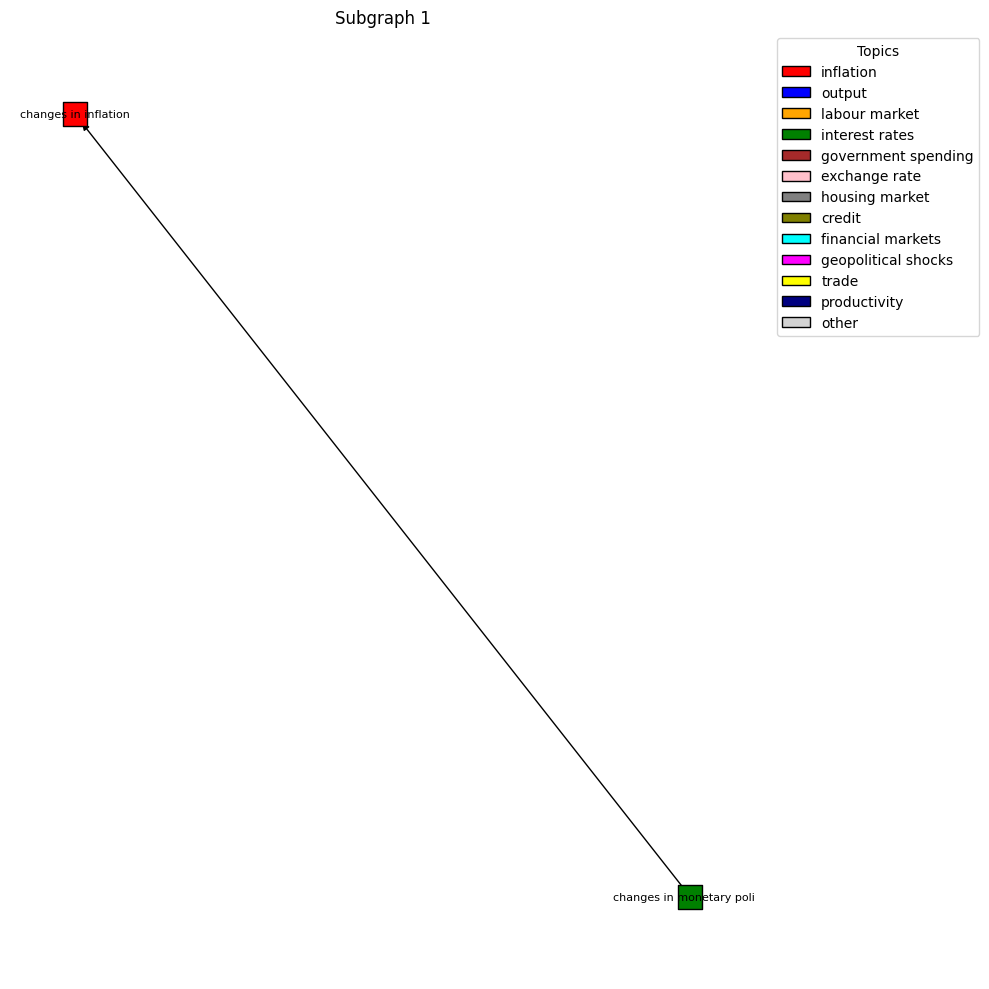


Subgraph 2: 2 nodes, 1 edges


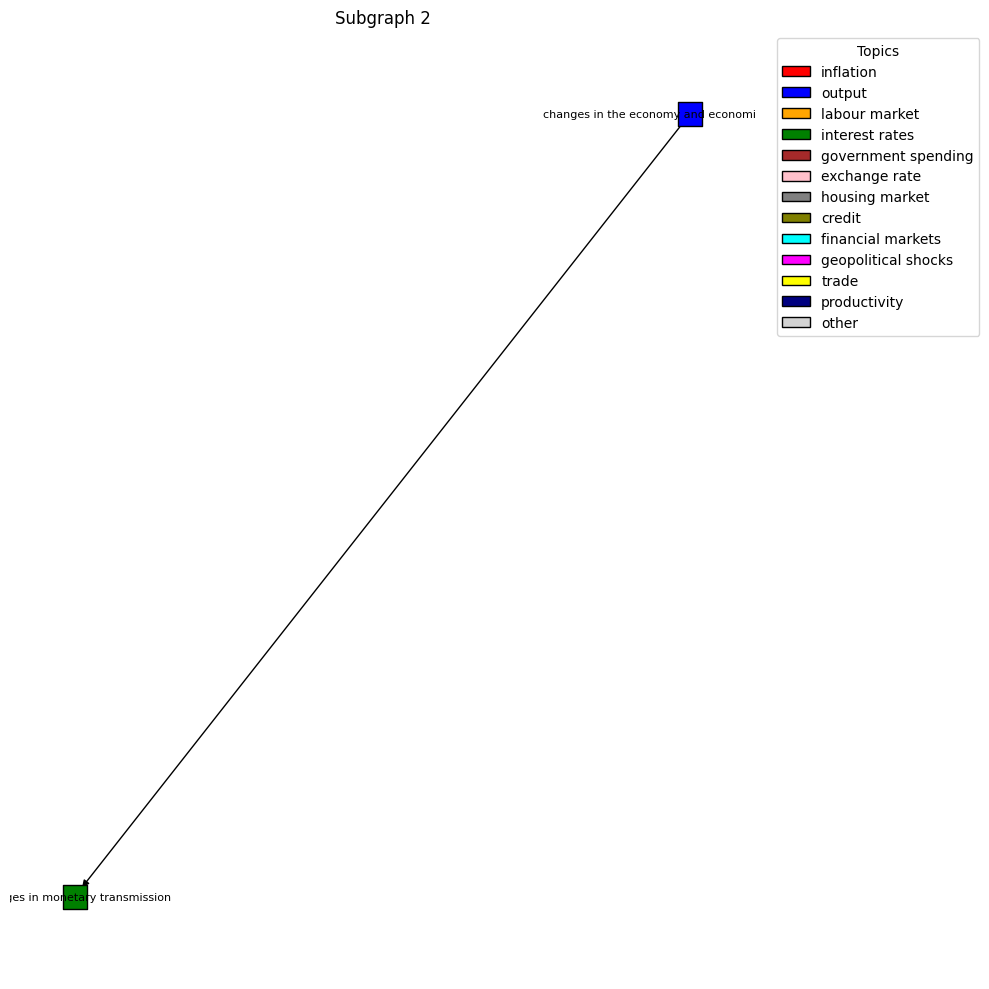


Subgraph 3: 2 nodes, 1 edges


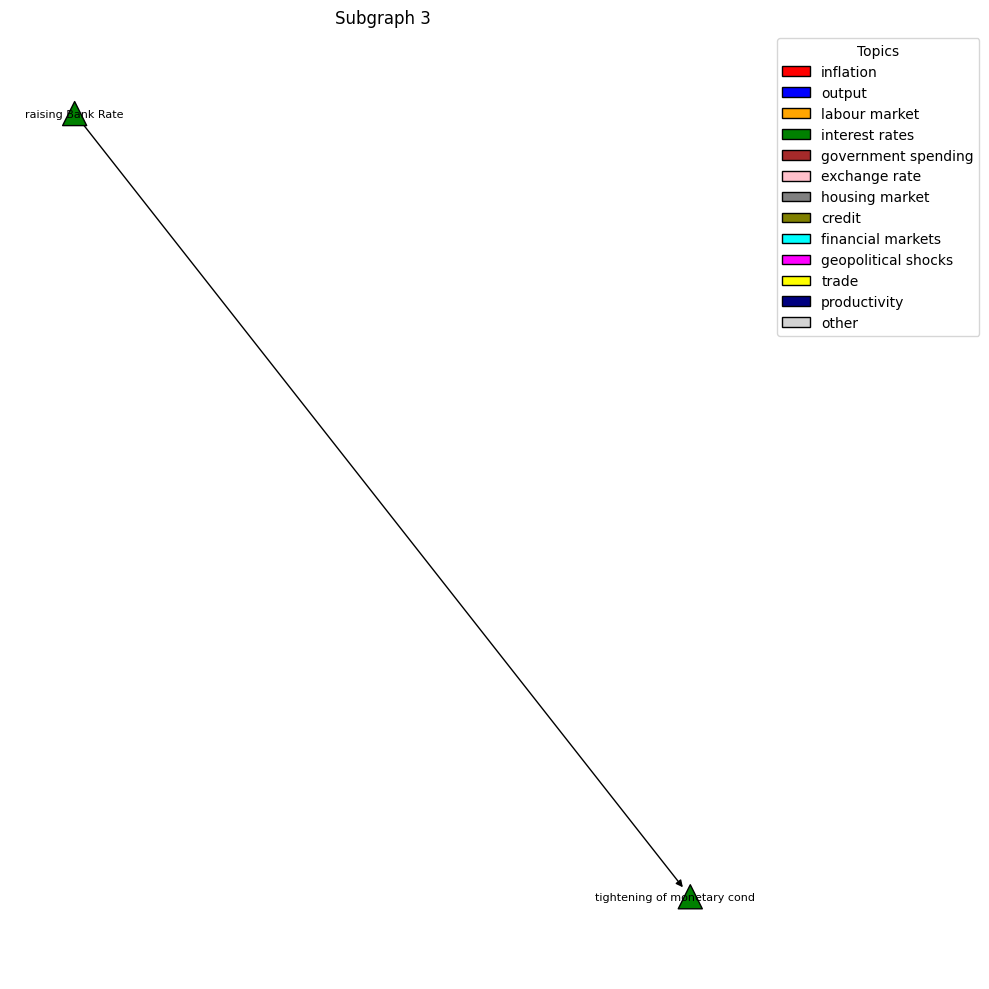


Subgraph 4: 3 nodes, 2 edges


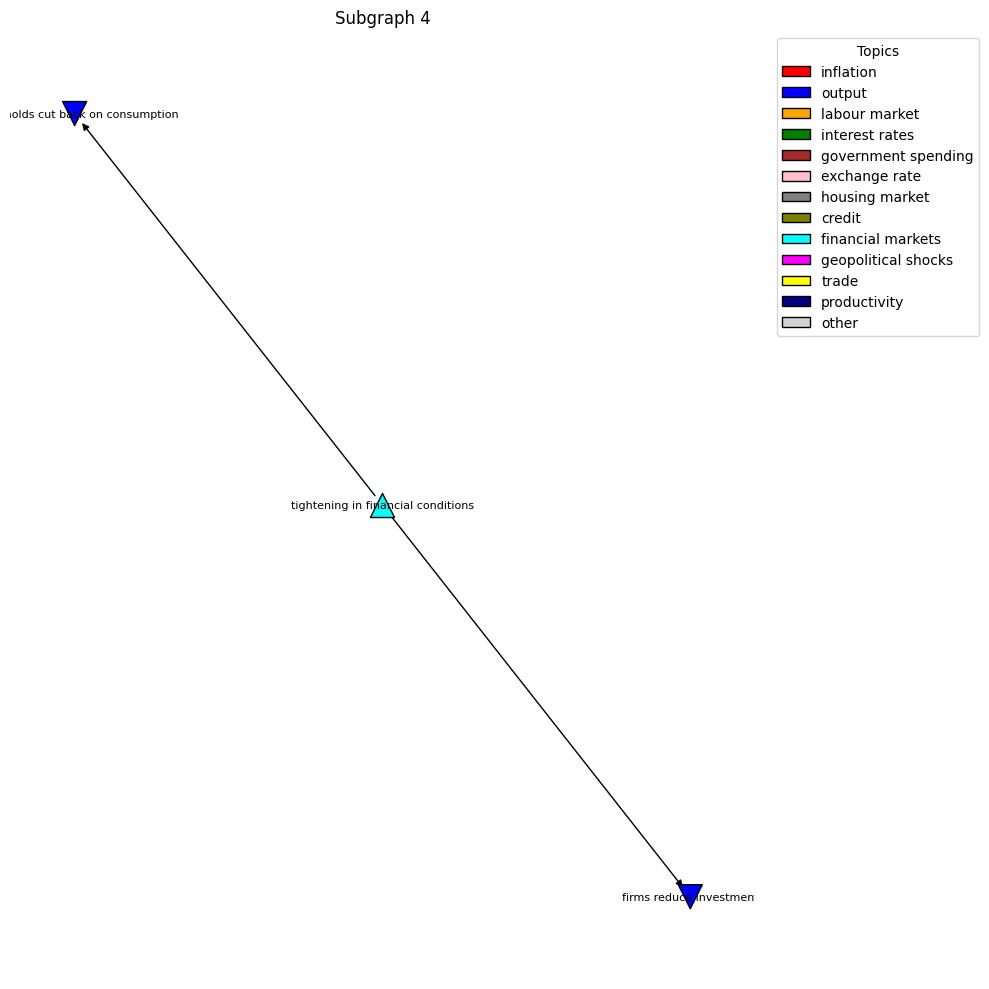


Subgraph 5: 2 nodes, 1 edges


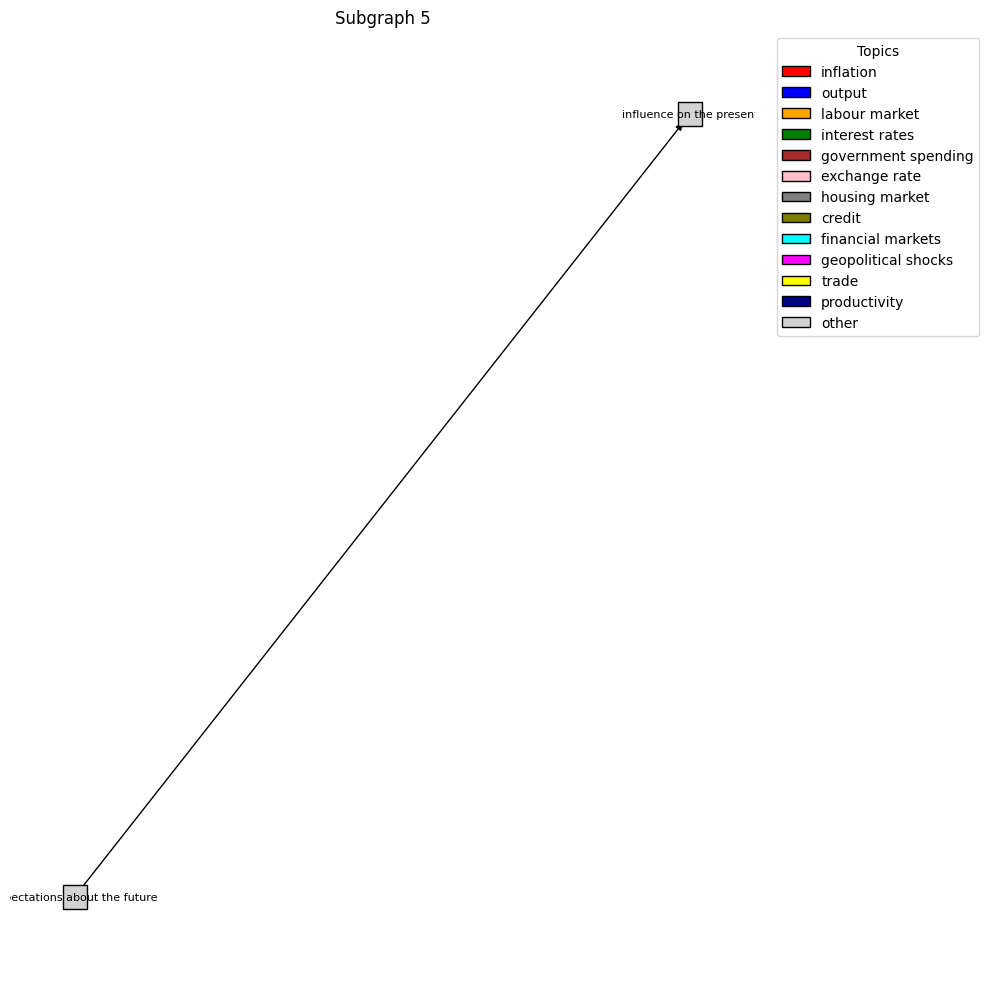


Subgraph 6: 2 nodes, 1 edges


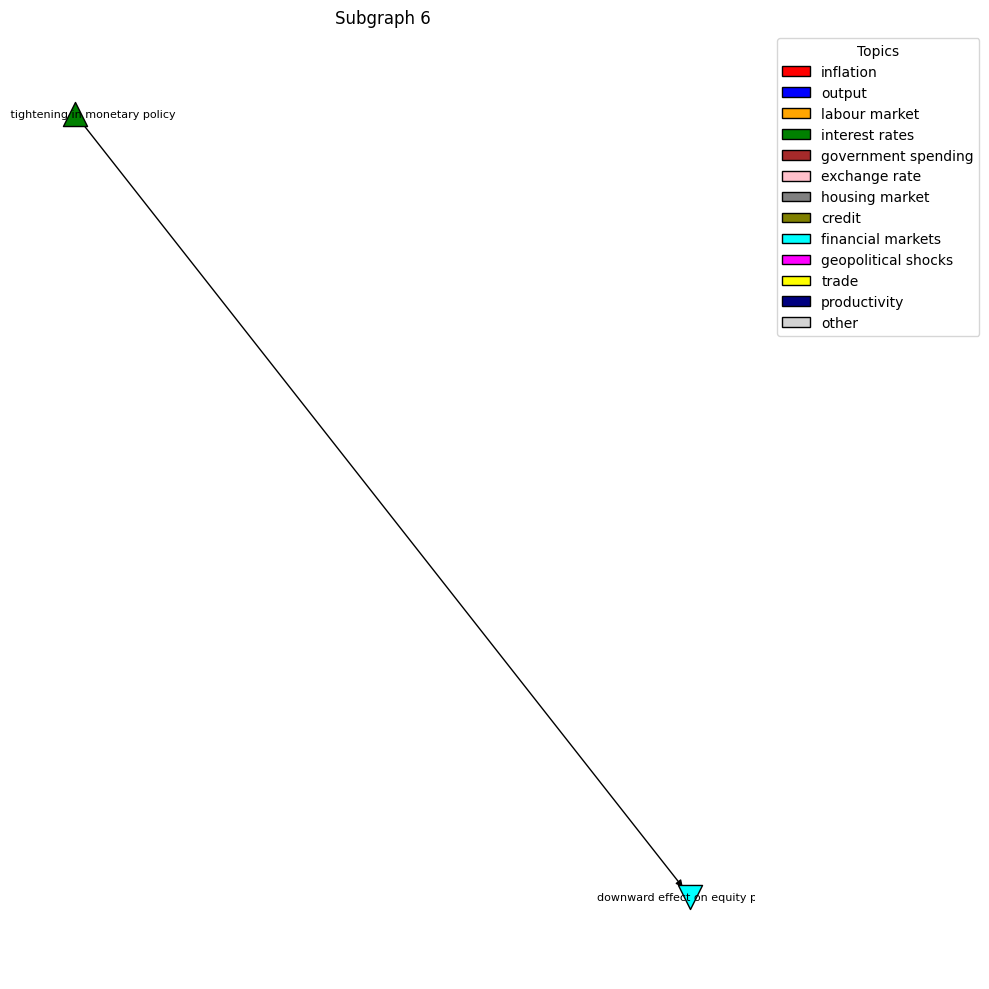


Subgraph 7: 3 nodes, 2 edges


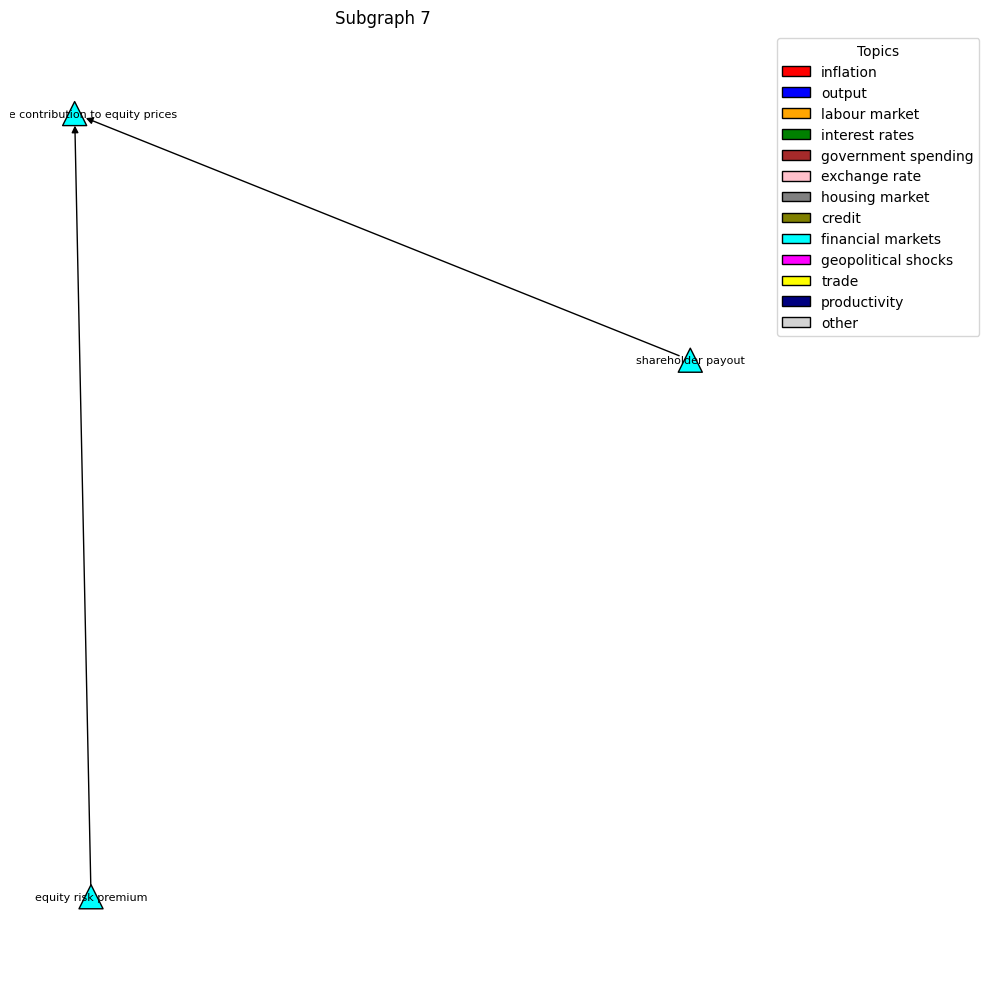


Subgraph 8: 2 nodes, 1 edges


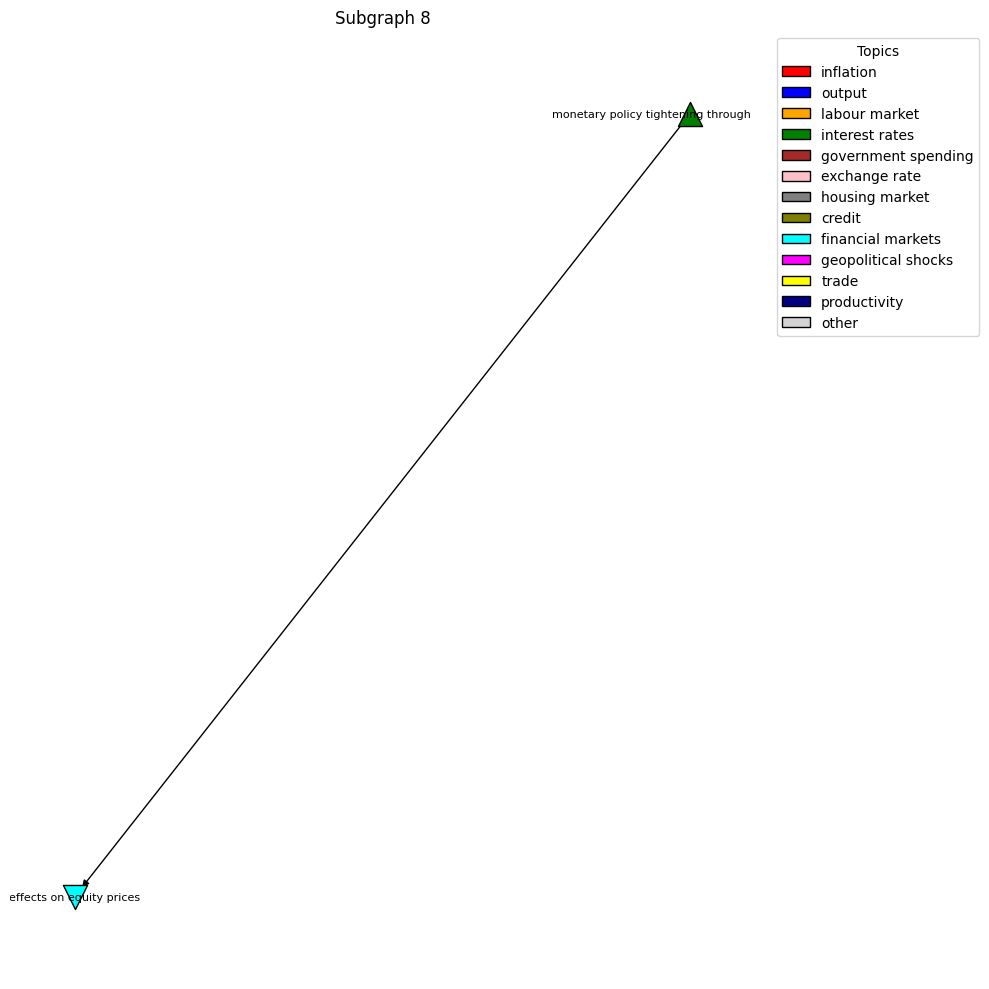


Subgraph 9: 2 nodes, 1 edges


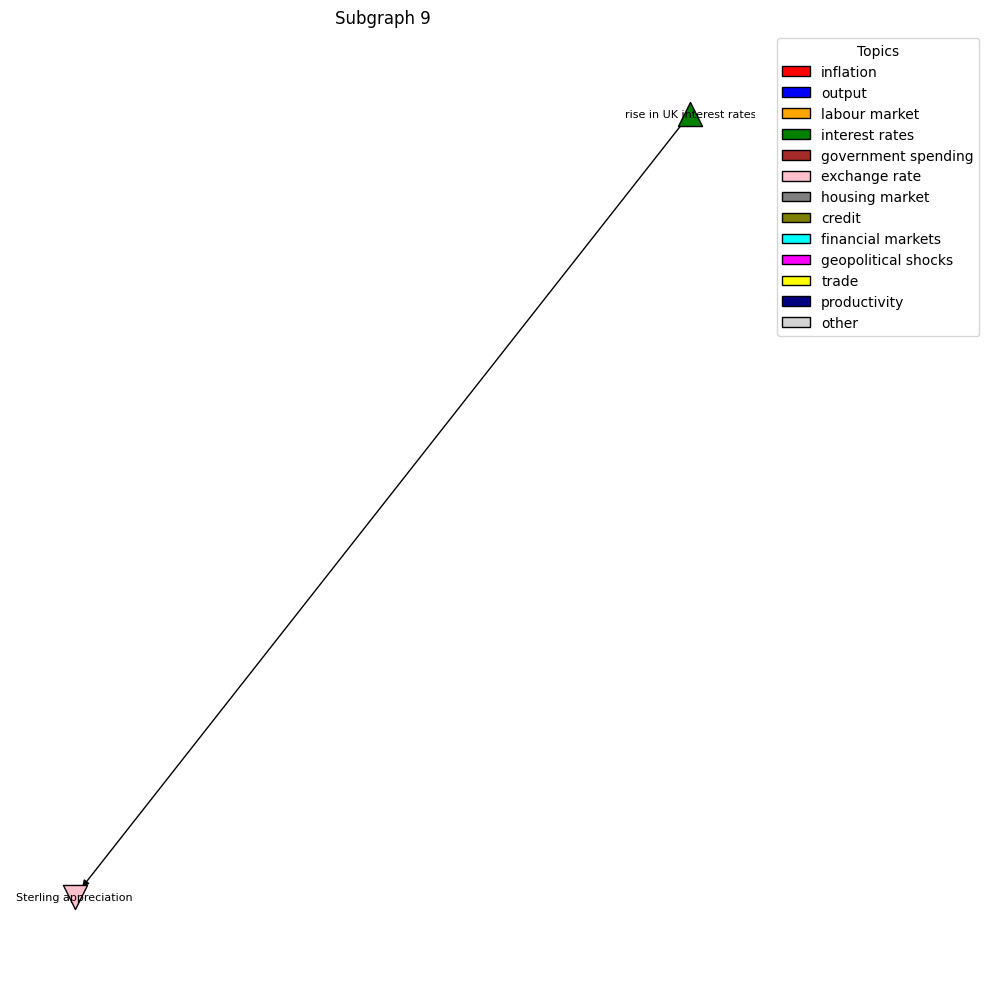


Subgraph 10: 3 nodes, 2 edges


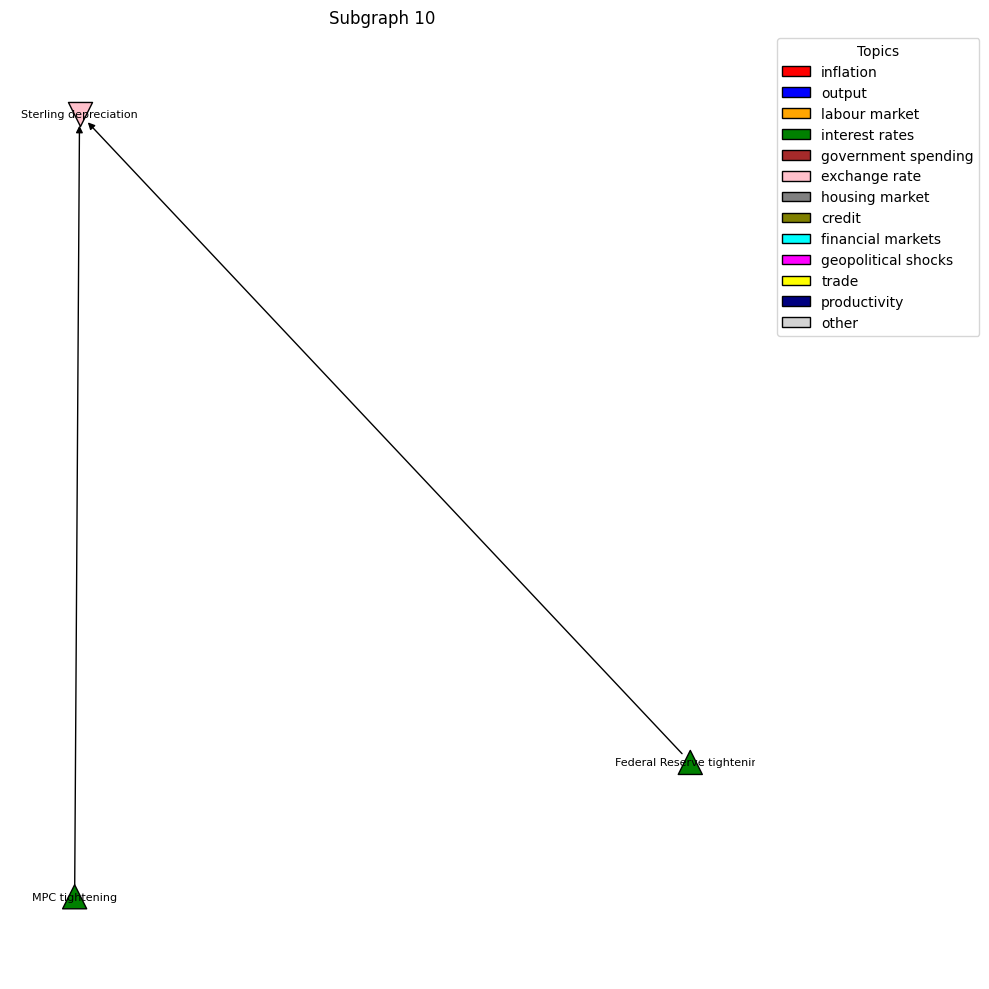


Subgraph 11: 2 nodes, 1 edges


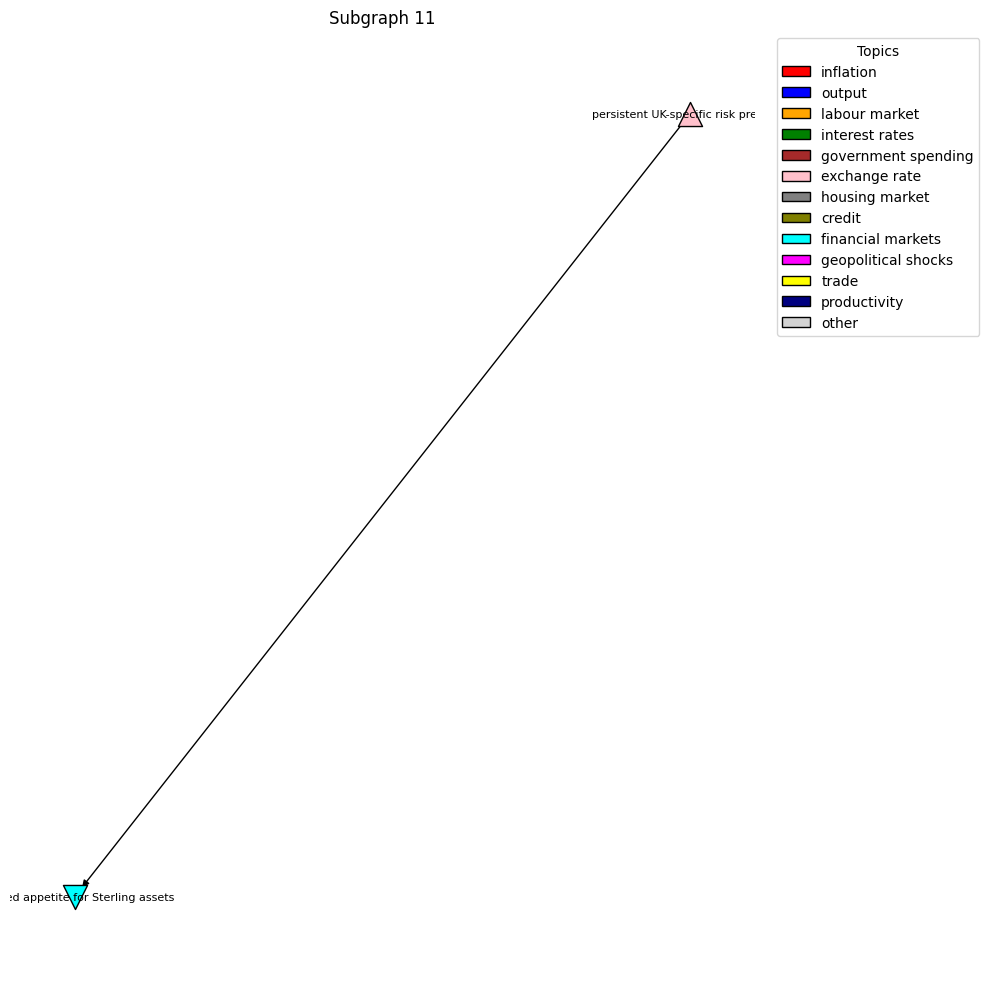


Subgraph 12: 3 nodes, 2 edges


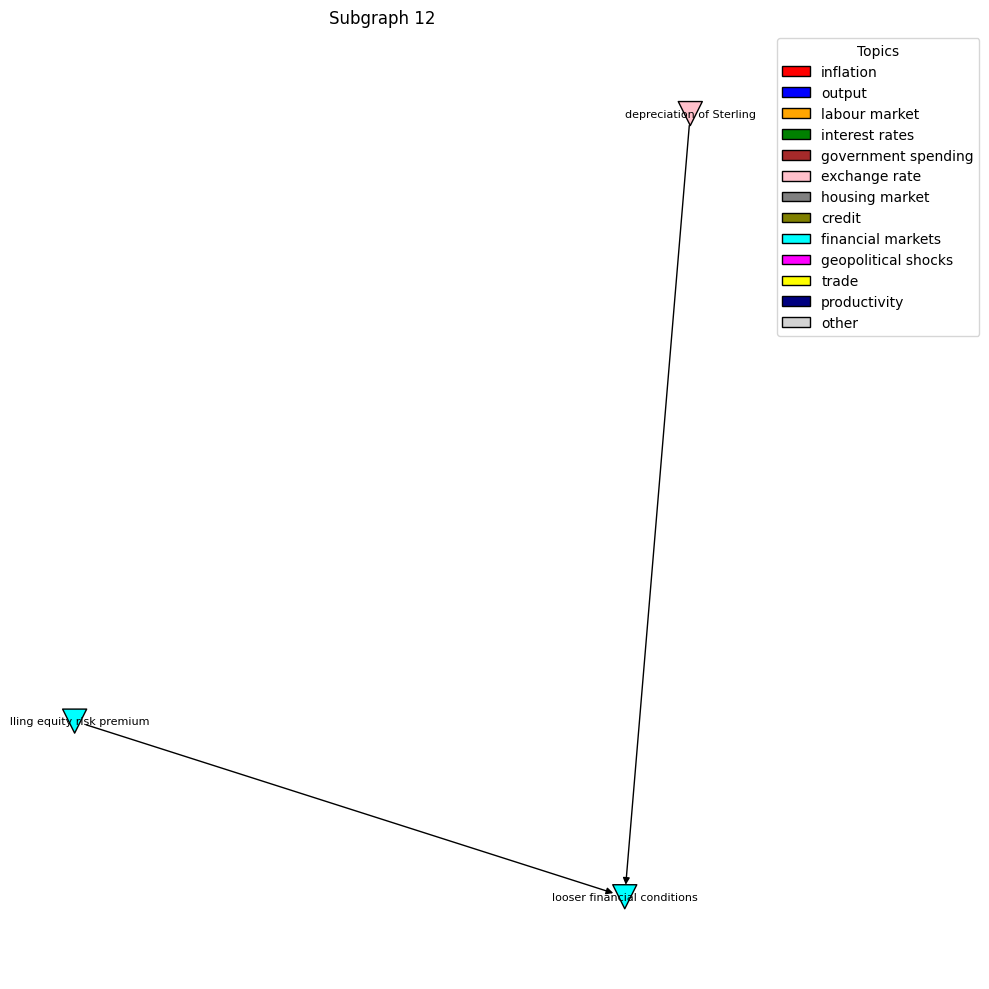


Subgraph 13: 4 nodes, 3 edges


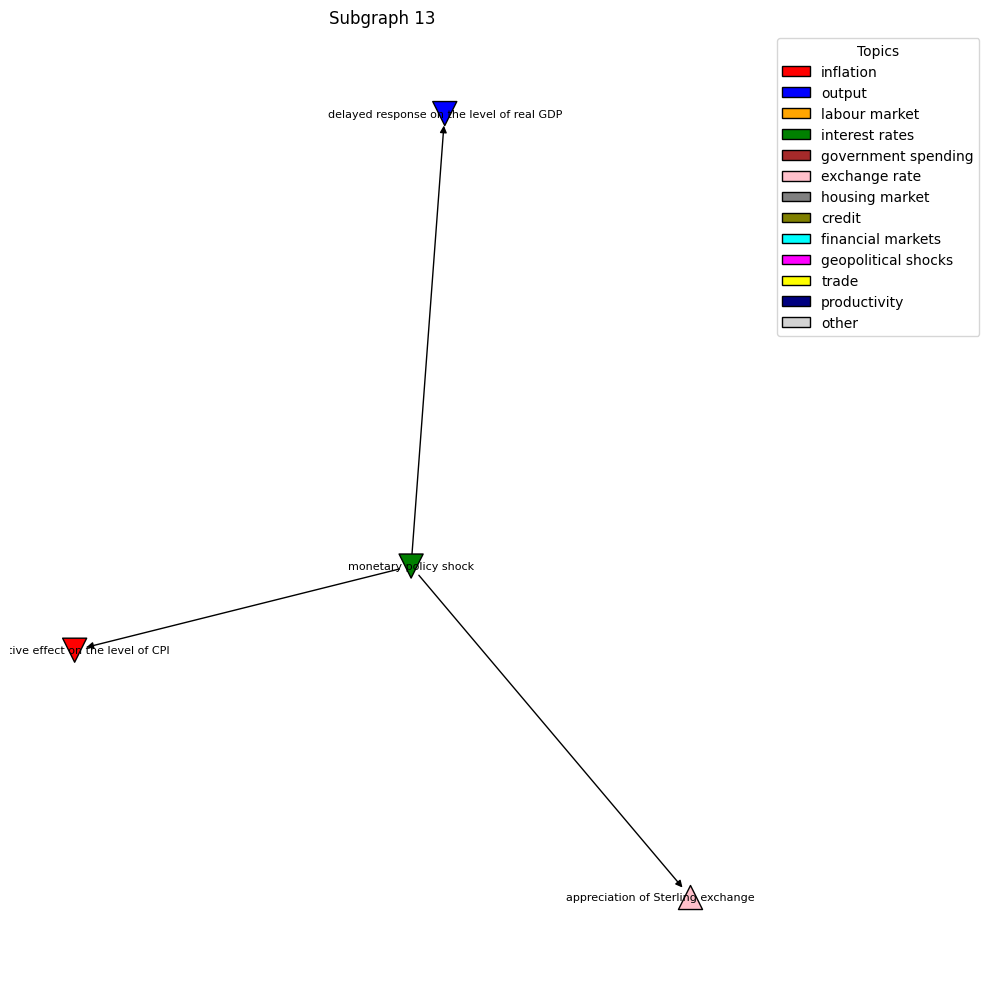


Subgraph 14: 2 nodes, 1 edges


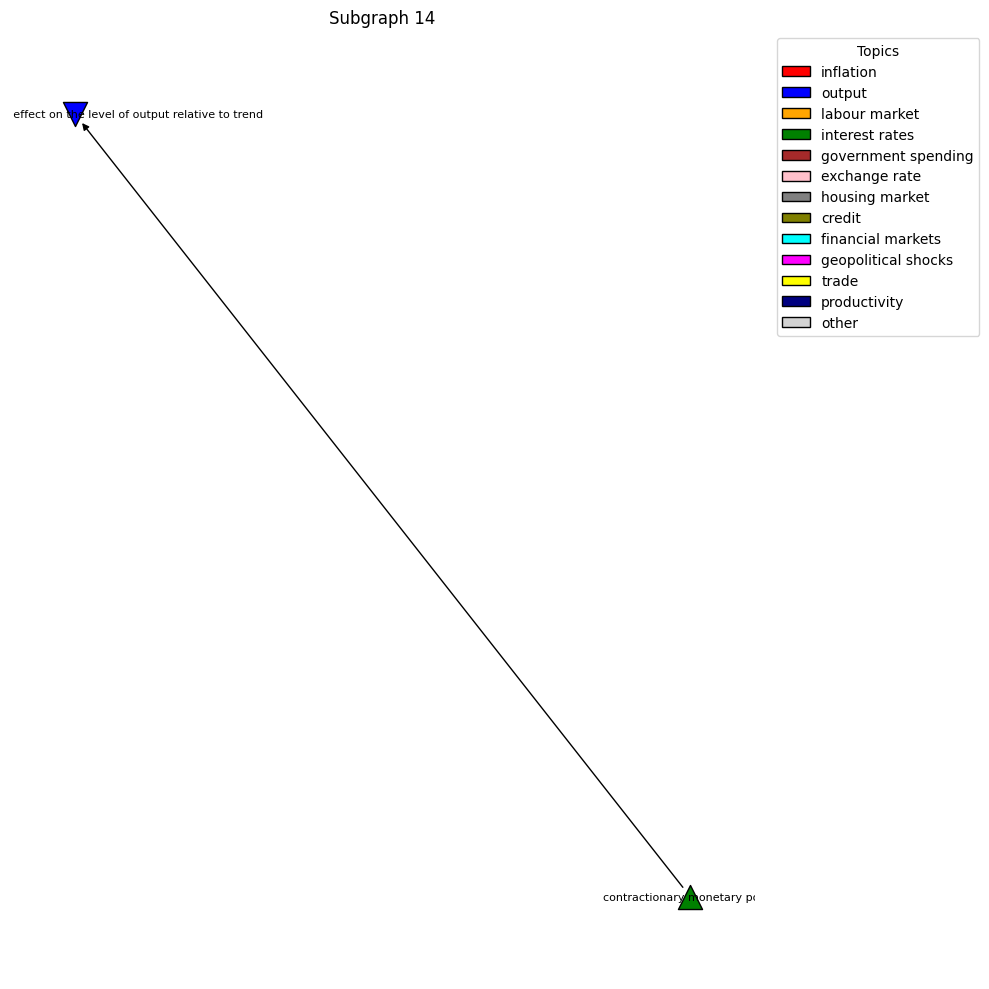


Subgraph 15: 2 nodes, 1 edges


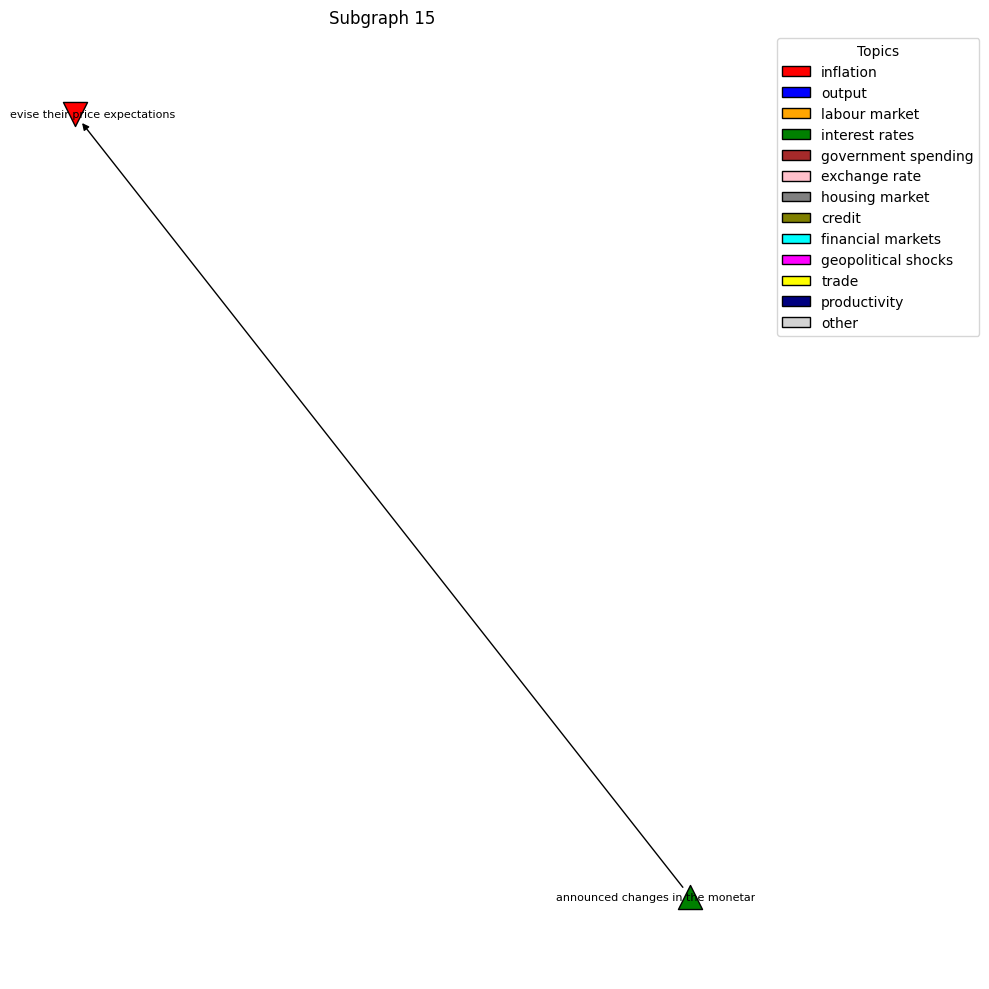


Subgraph 16: 2 nodes, 1 edges


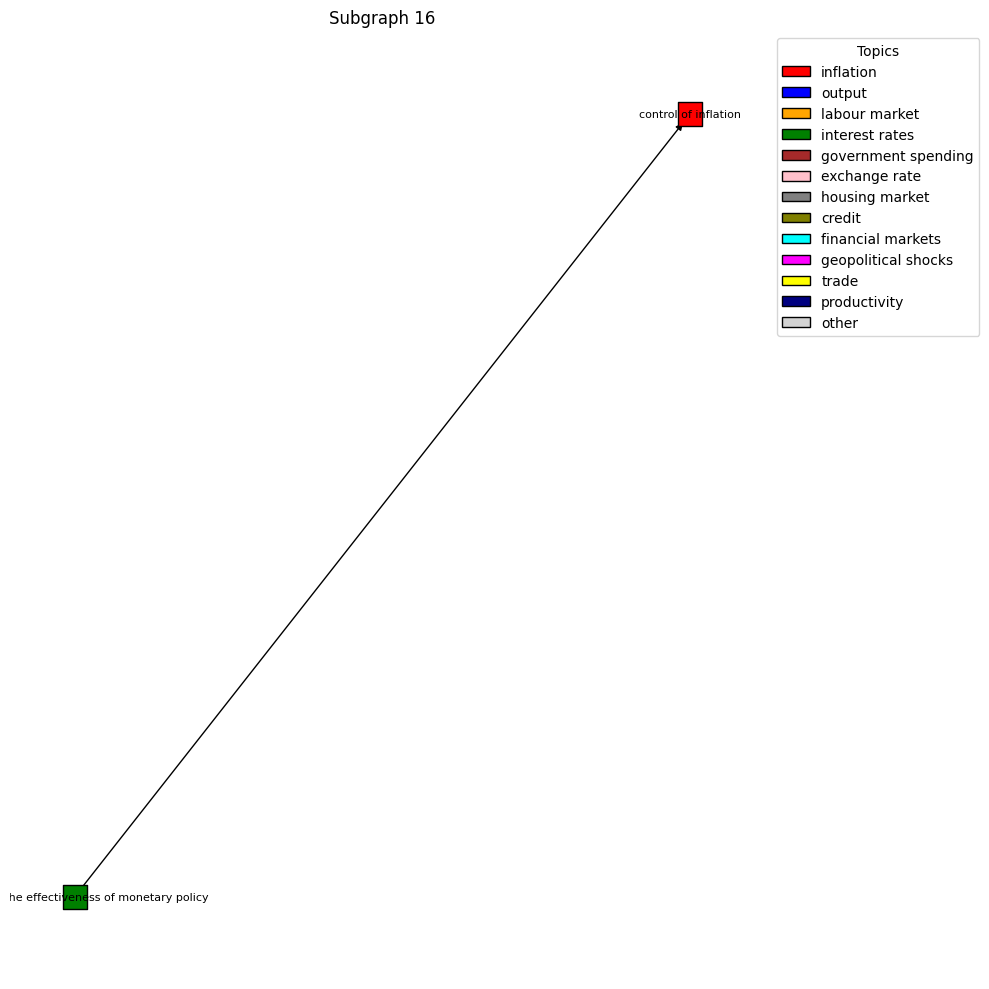


Subgraph 17: 2 nodes, 1 edges


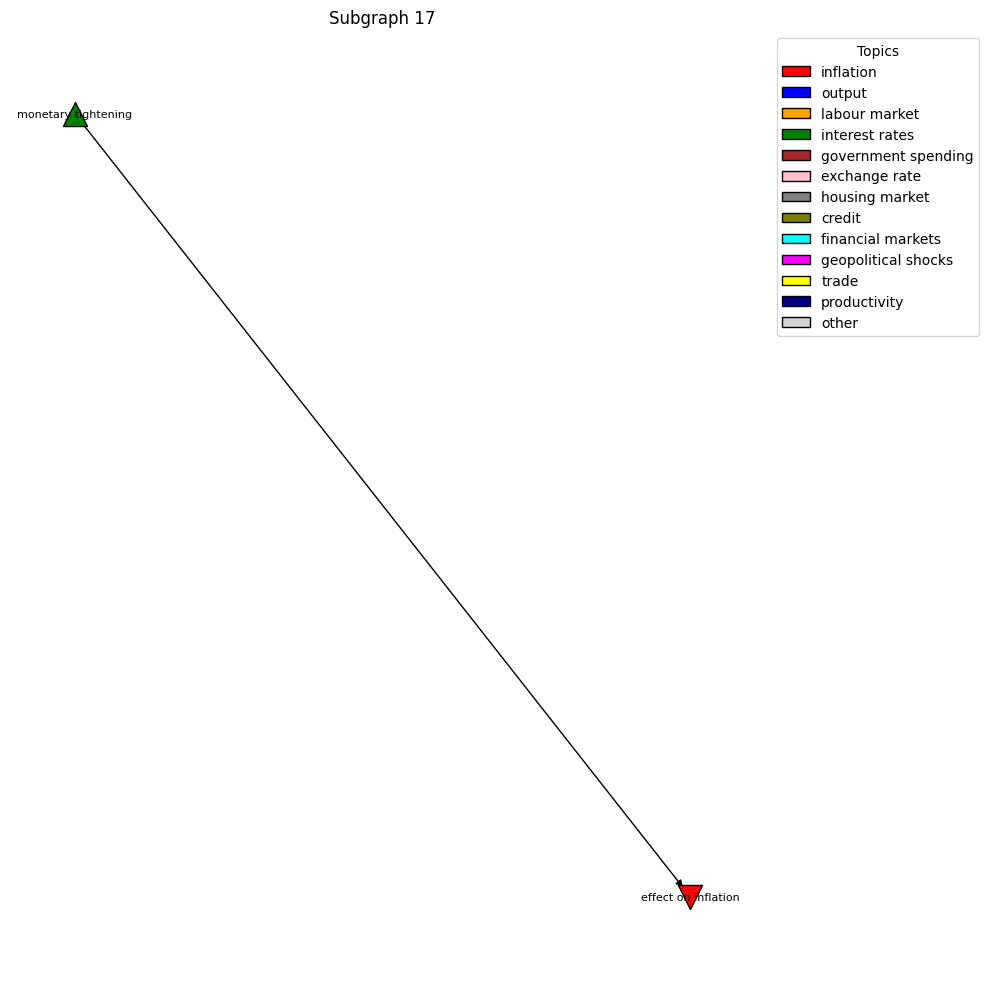


Subgraph 18: 2 nodes, 1 edges


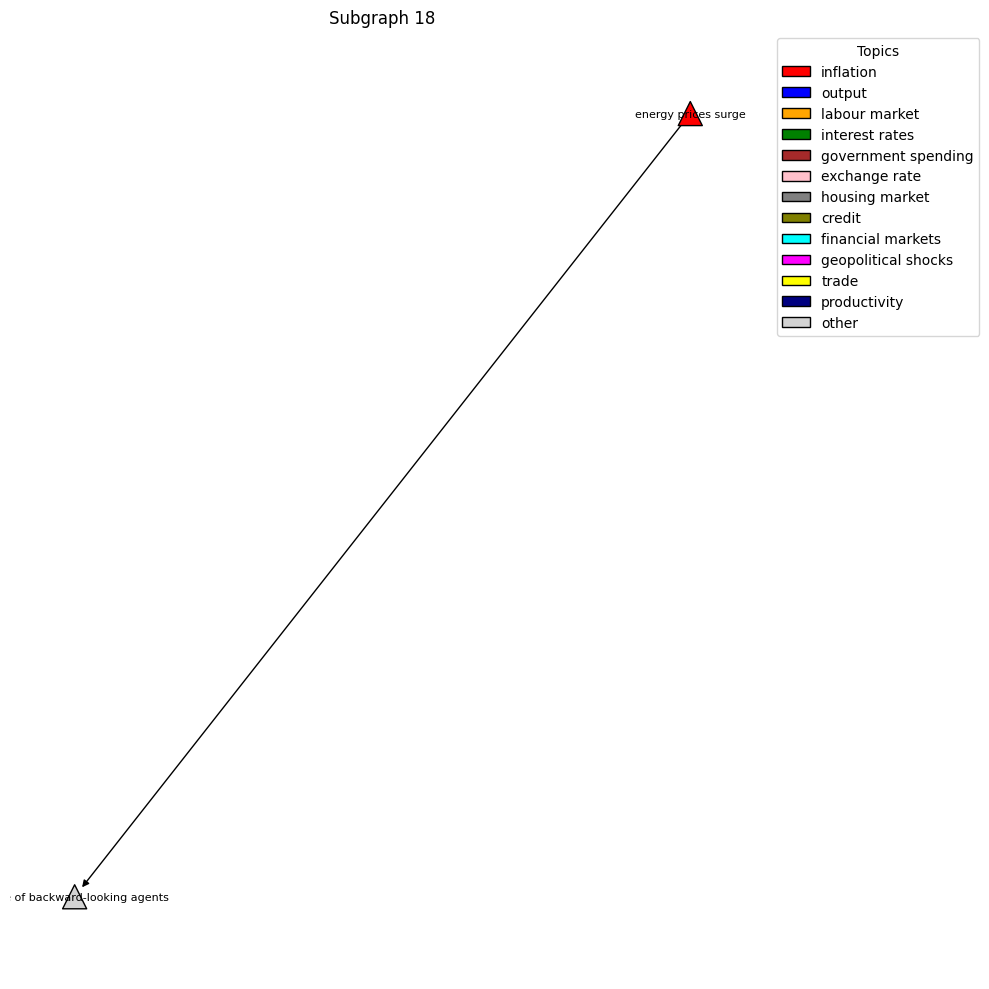


Subgraph 19: 3 nodes, 2 edges


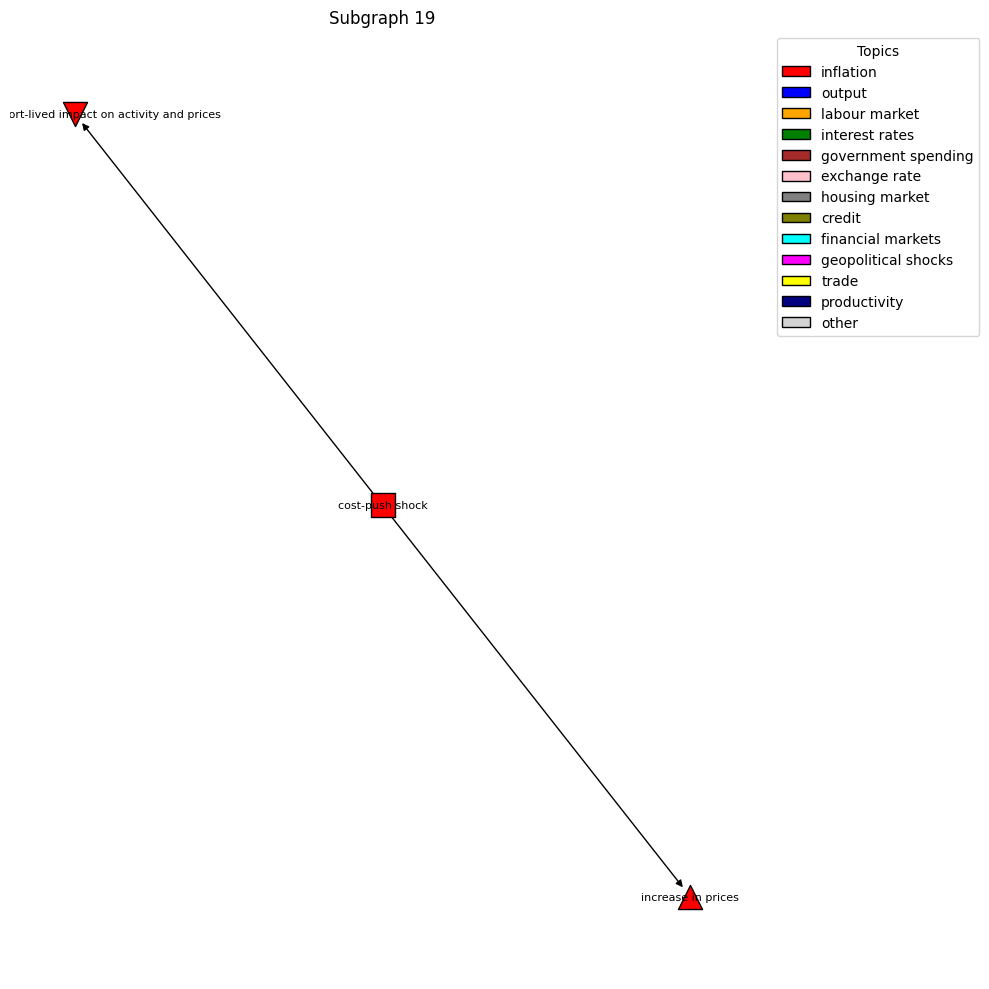


Subgraph 20: 2 nodes, 1 edges


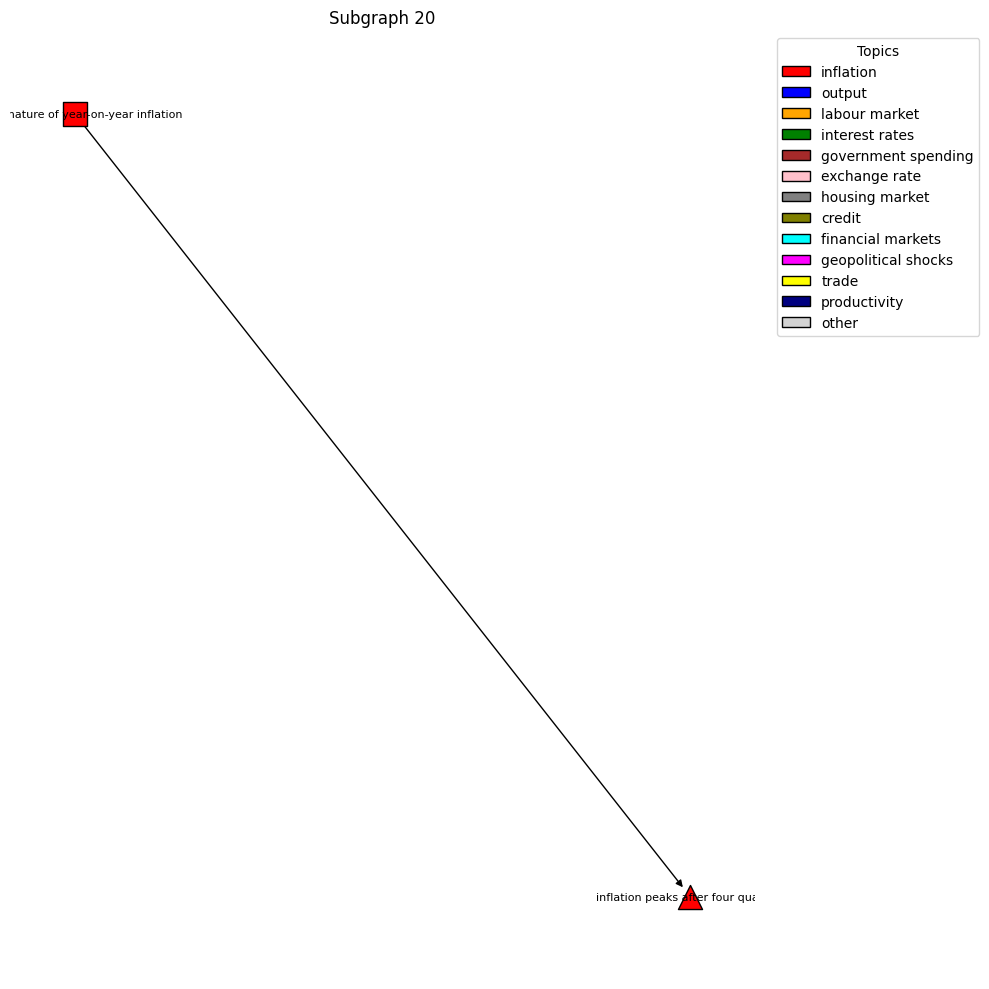


Subgraph 21: 3 nodes, 2 edges


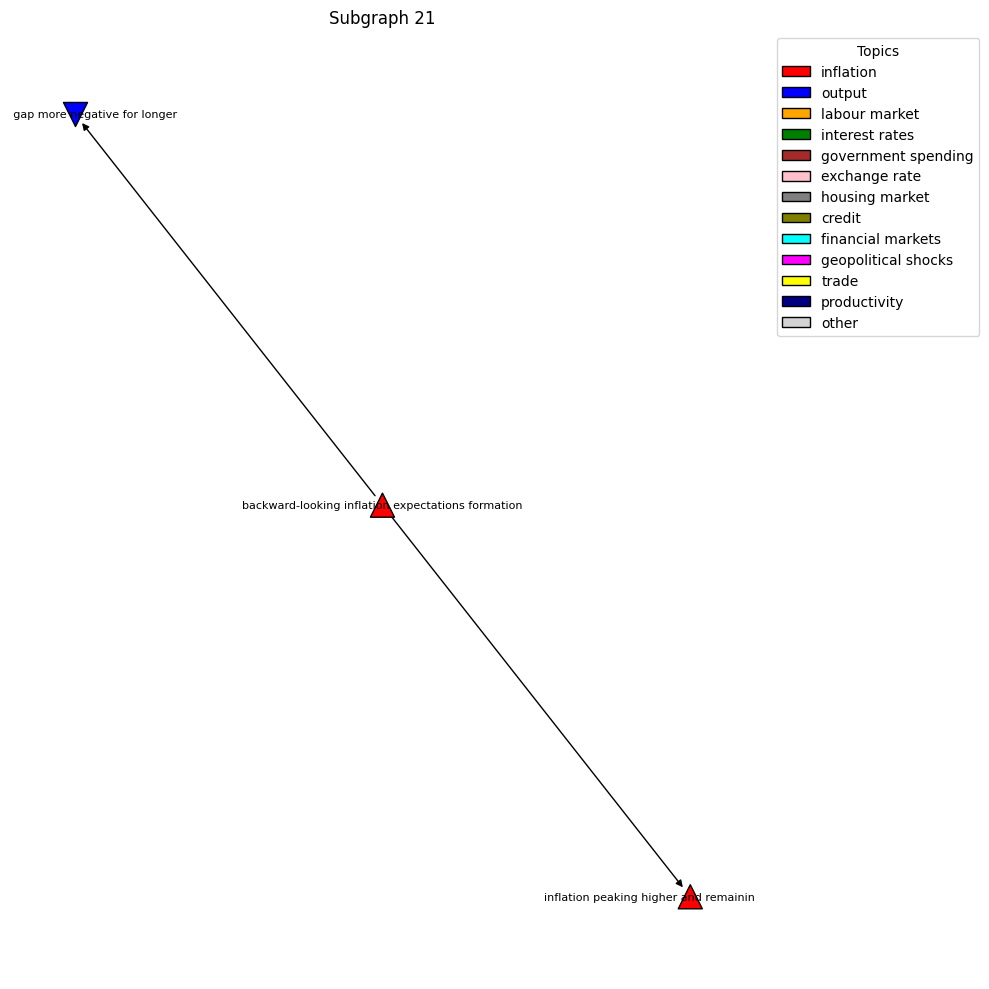


Subgraph 22: 2 nodes, 1 edges


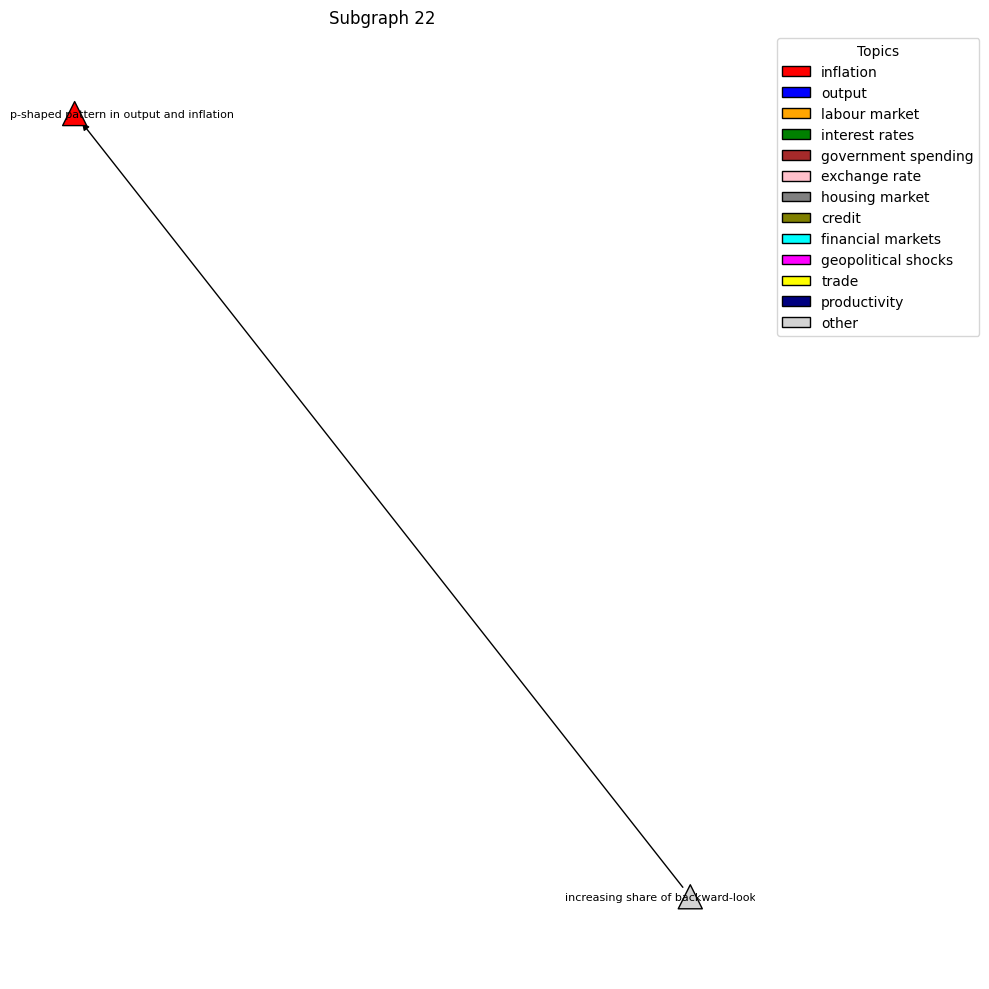


Subgraph 23: 2 nodes, 1 edges


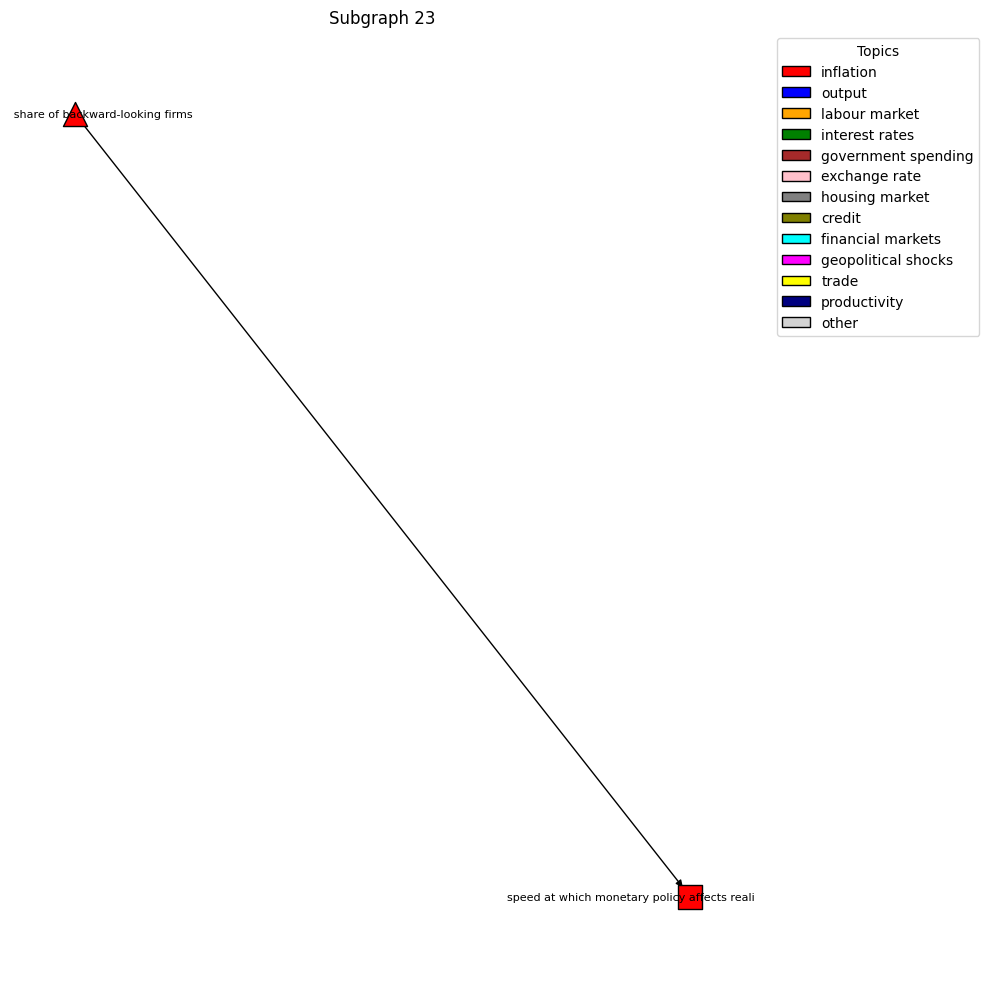


Subgraph 24: 2 nodes, 1 edges


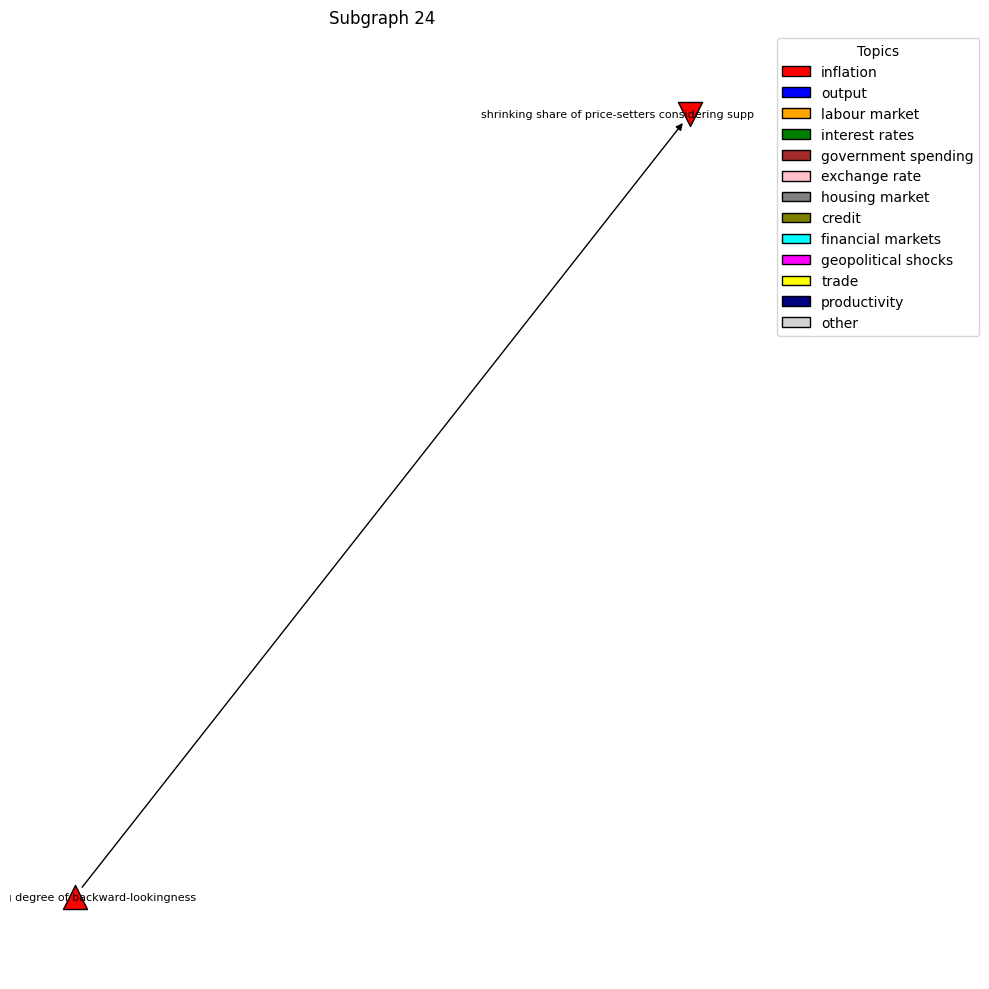


Subgraph 25: 2 nodes, 1 edges


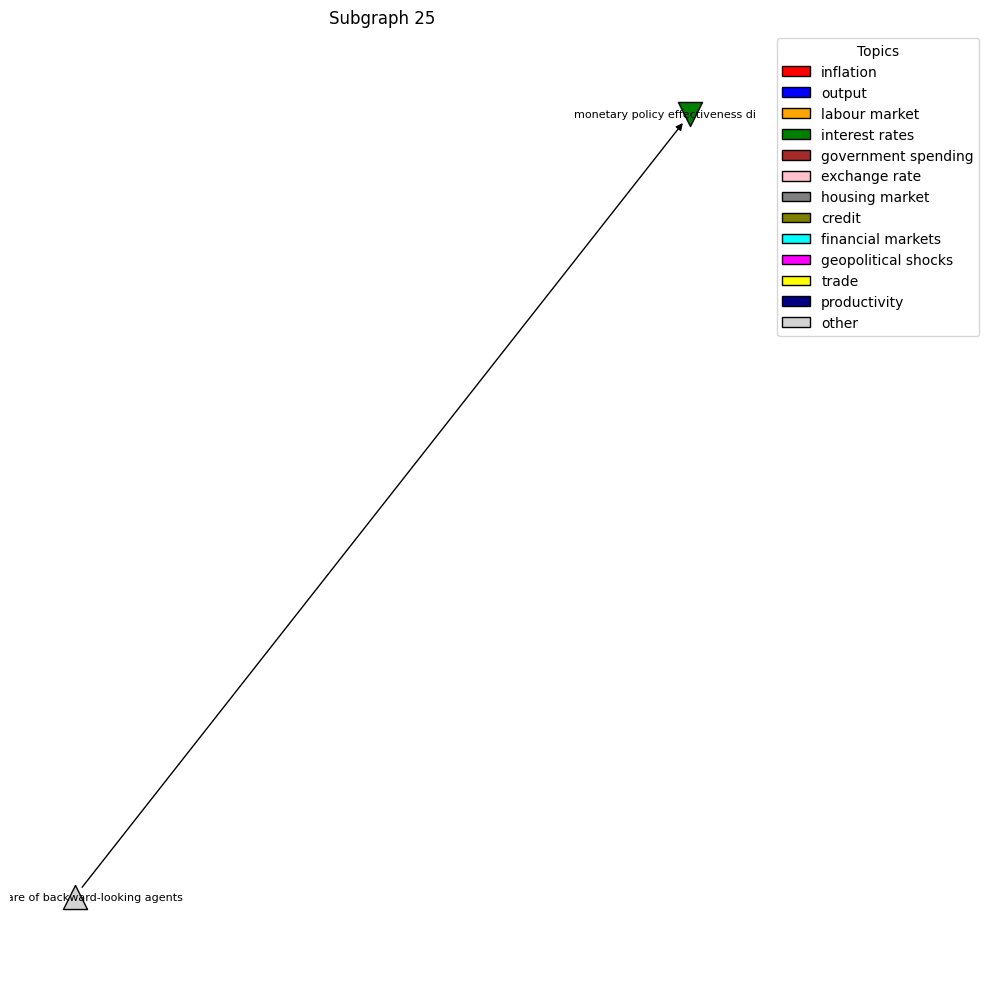


Subgraph 26: 2 nodes, 1 edges


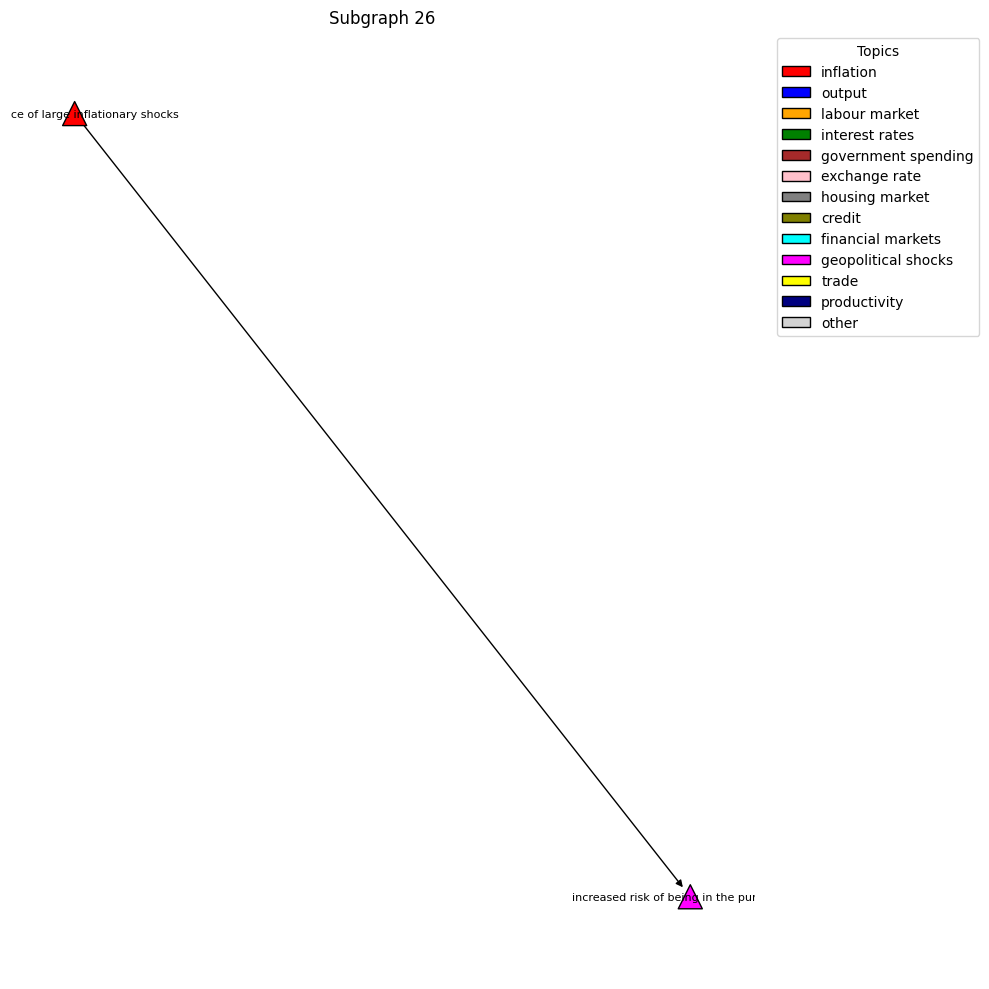


Subgraph 27: 3 nodes, 2 edges


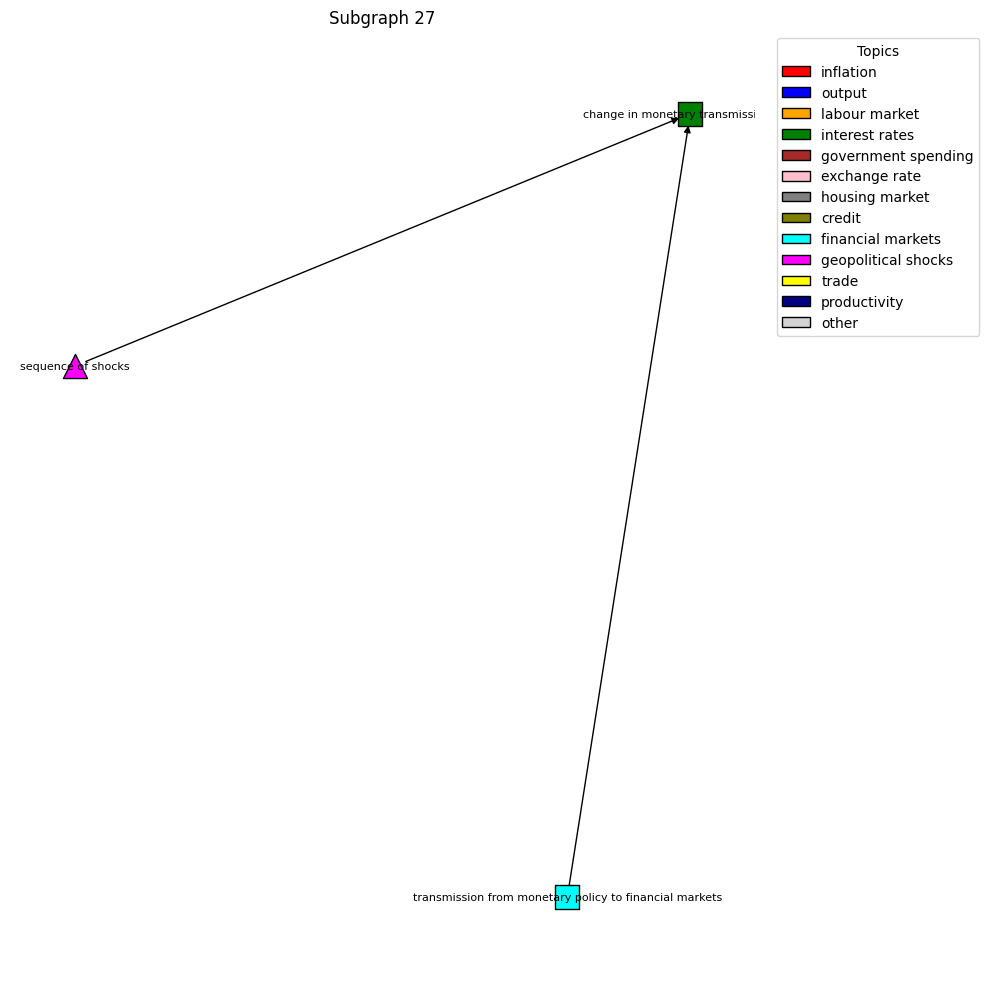


Subgraph 28: 2 nodes, 1 edges


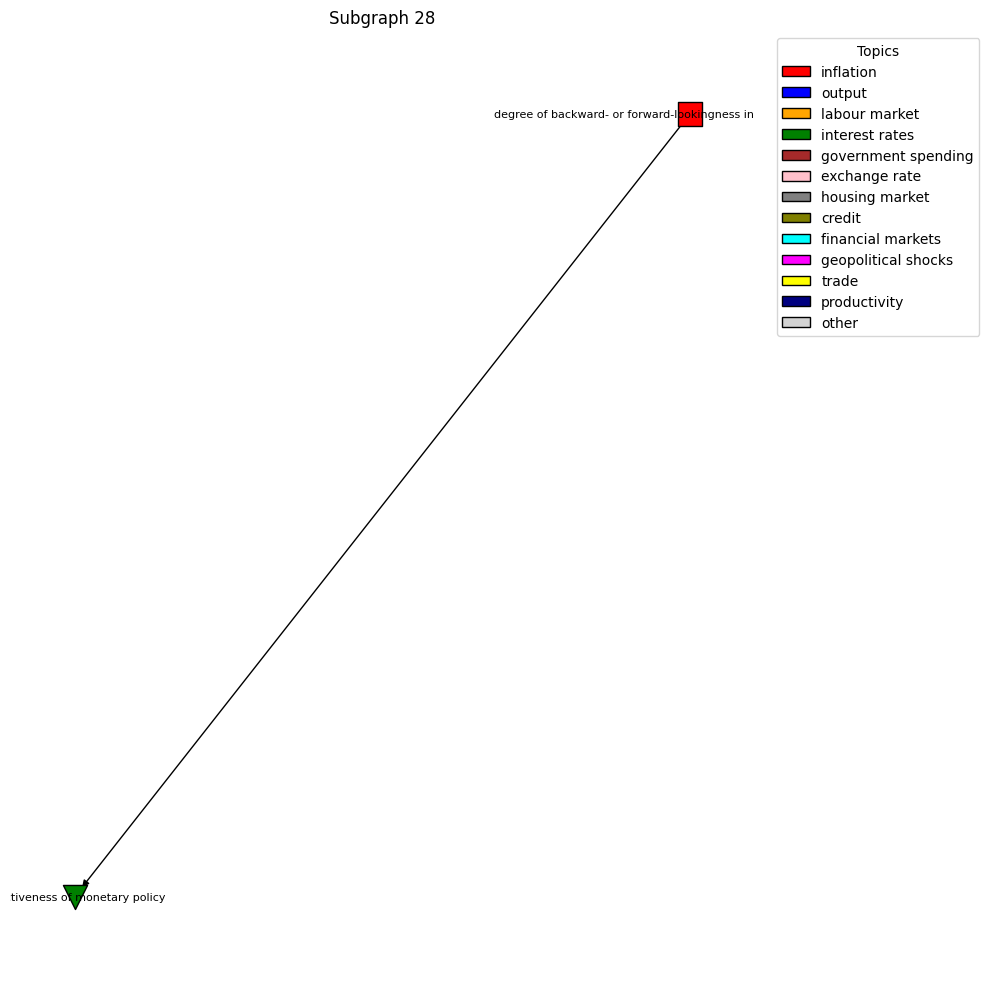


Subgraph 29: 2 nodes, 1 edges


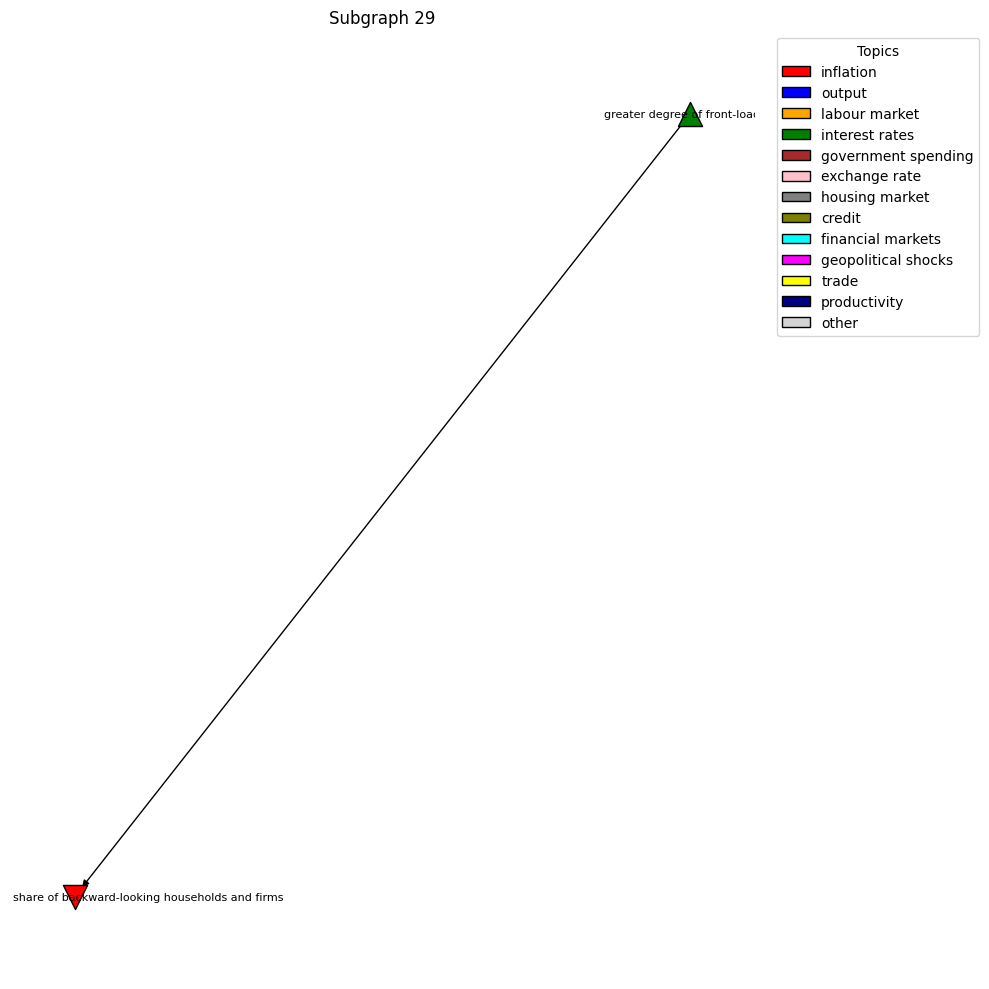


Subgraph 30: 2 nodes, 1 edges


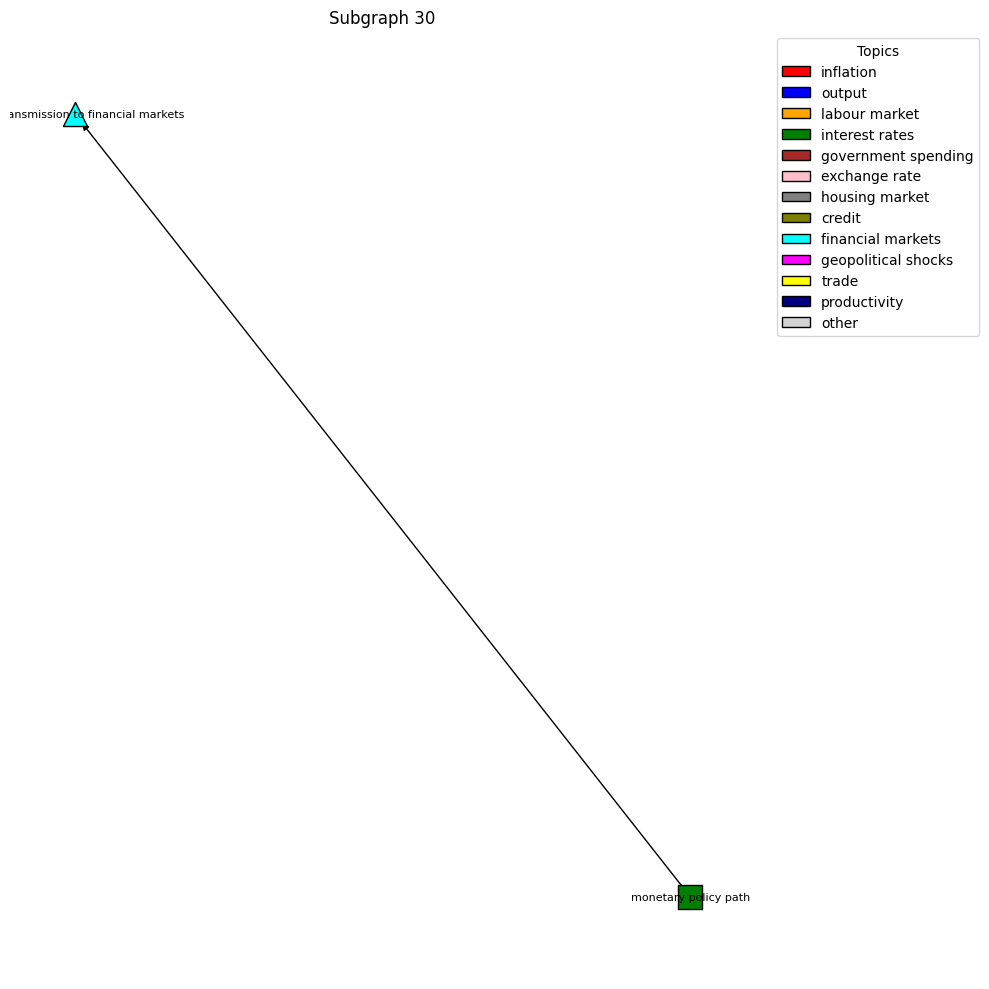


Subgraph 31: 2 nodes, 1 edges


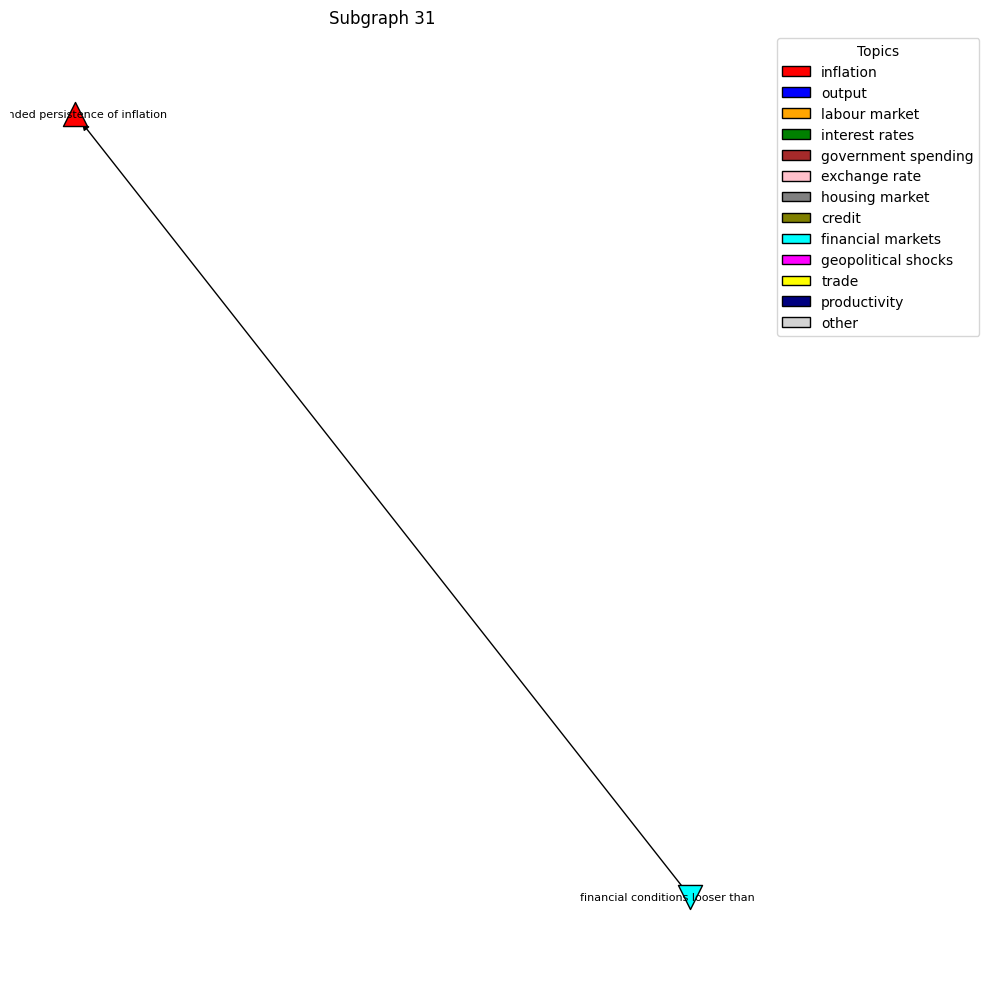


Subgraph 32: 2 nodes, 1 edges


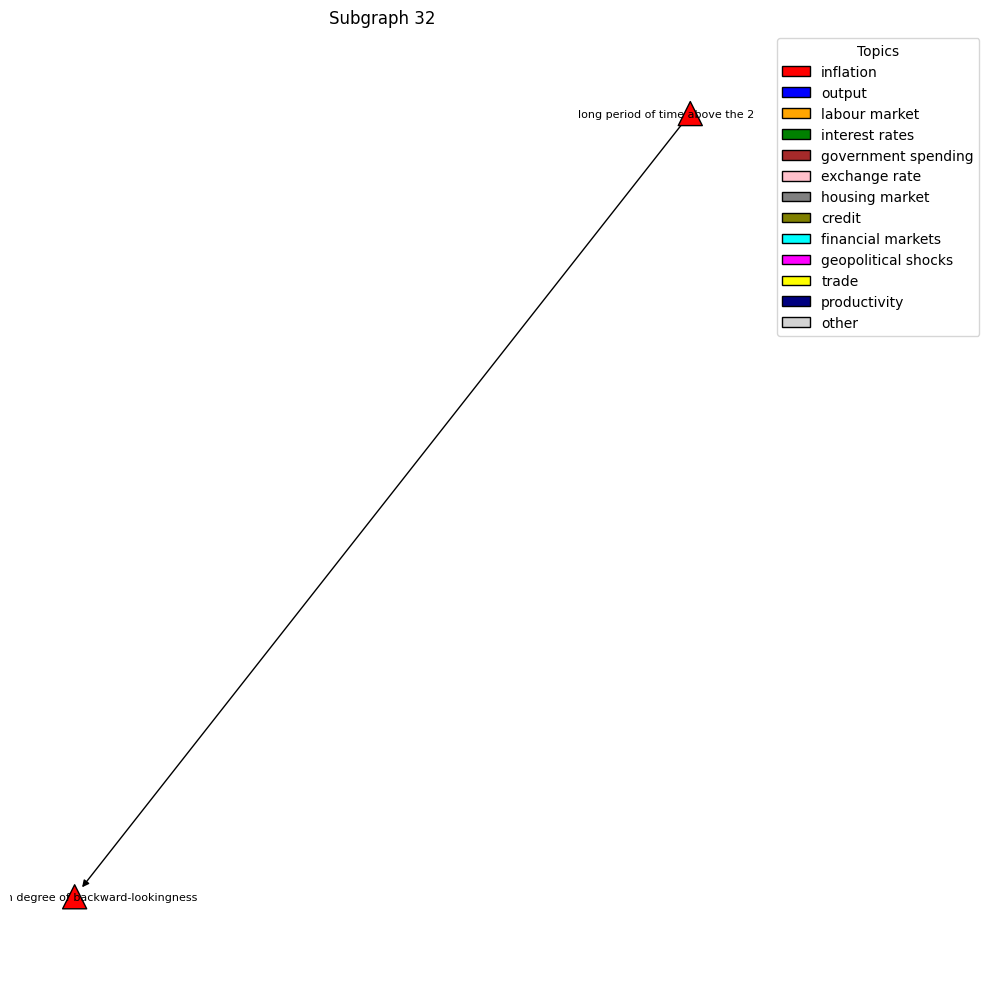


Subgraph 33: 2 nodes, 1 edges


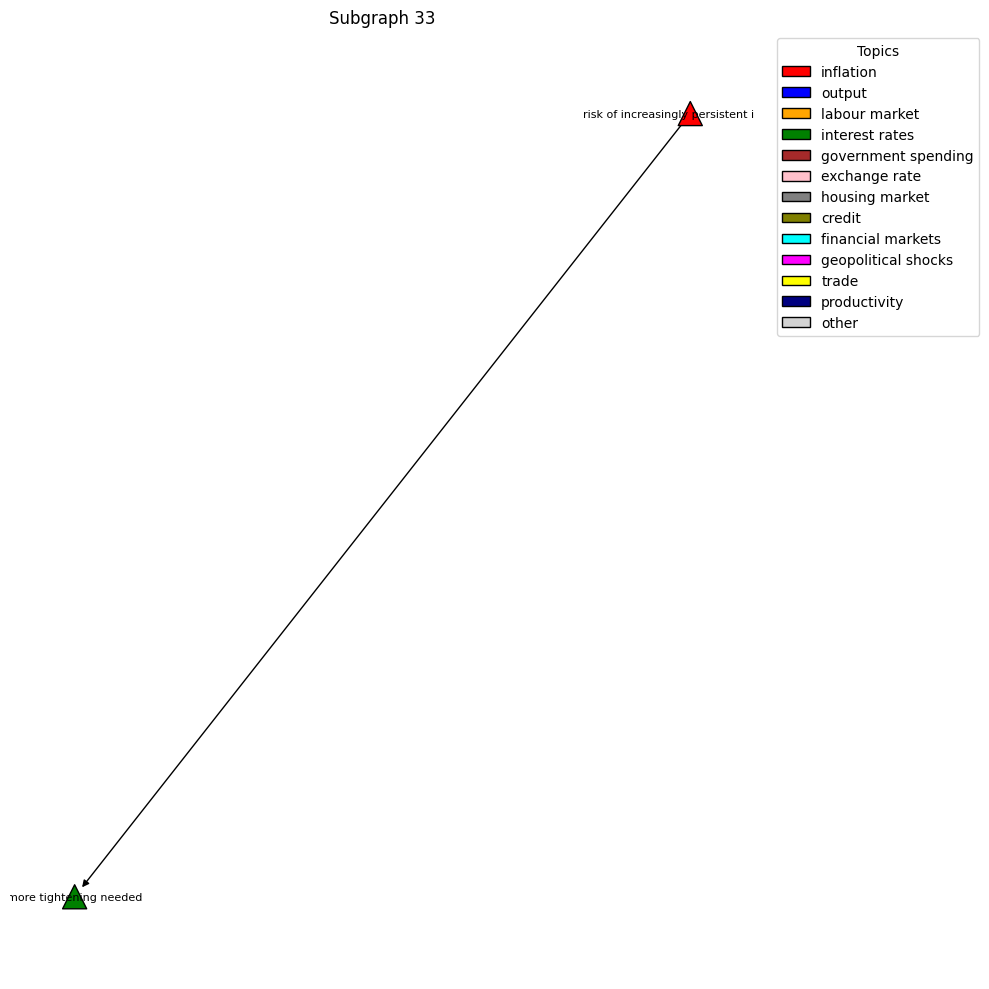


Subgraph 34: 2 nodes, 1 edges


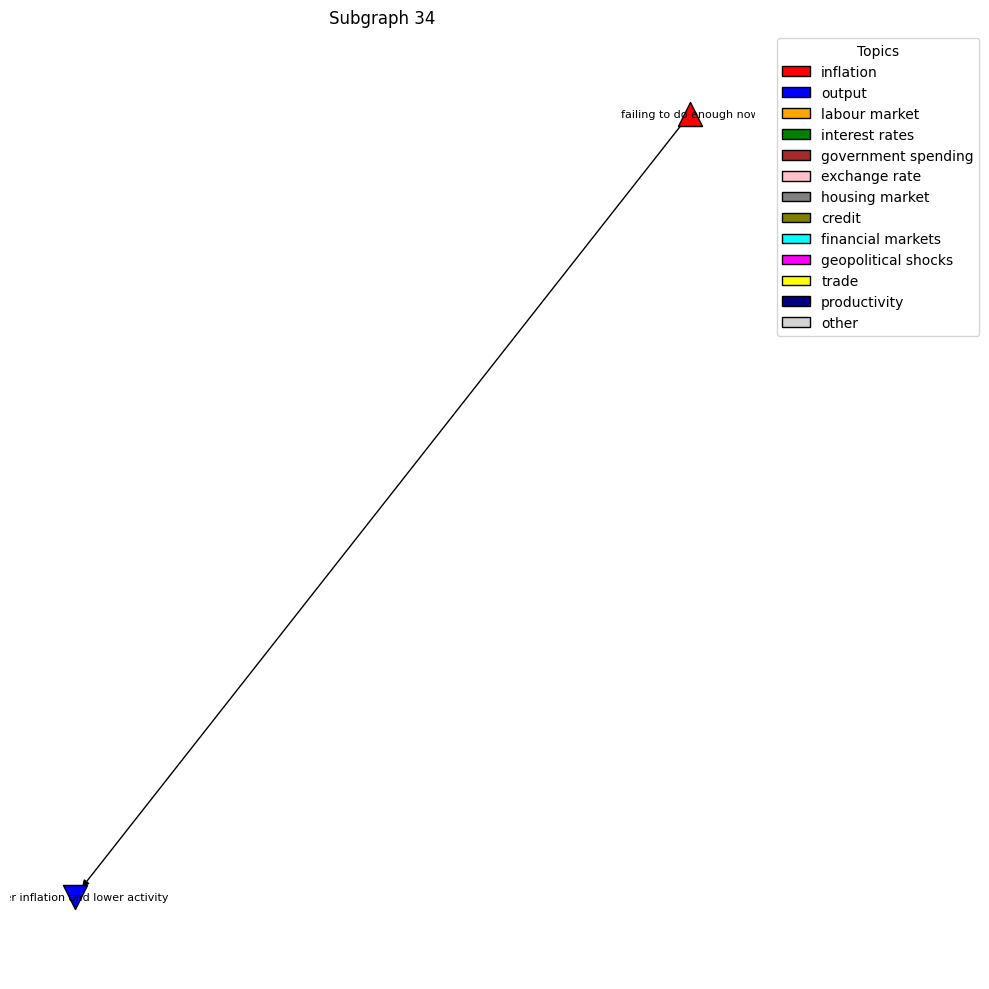


Subgraph 35: 3 nodes, 2 edges


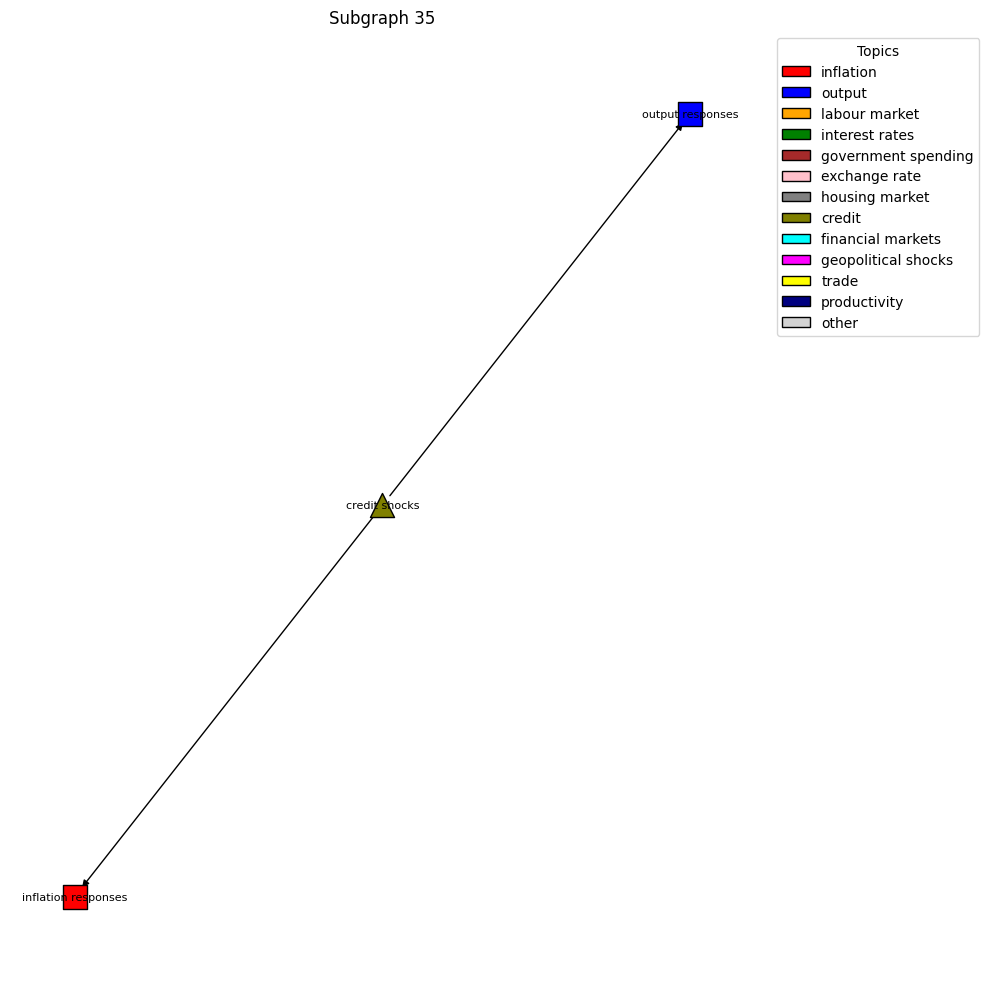

In [ ]:
# get it to run for each of the individual speech_id separately ( one graph per speech_id  )
for speech_id in [16653]:#completed_entities_df['speech_id'].unique():
    speech_df = completed_entities_df[completed_entities_df['speech_id'] == speech_id]
    print(f"Graph for Speech ID: {speech_id}")
    plot_entity_subgraphs(speech_df)

In [ ]:
# Make a merge of the nodes that are of the same topic and classification together 

def merge_entities_by_topic_classification(completed_entities_df):
    """
    Merges entities that have the same topic and classification across different narratives.
    Creates a new dataframe with merged entity names and tracks the original entities.
    
    Returns:
        merged_df: DataFrame with merged entity names
        entity_mapping: Dictionary tracking which original entities were merged together
    """
    import pandas as pd
    
    # Create a copy to avoid modifying the original
    df = completed_entities_df.copy()
    
    # Track mappings for both cause and effect entities
    cause_mapping = {}
    effect_mapping = {}
    
    # Get unique combinations of topic and classification for causes
    cause_combos = df[['topic_cause', 'classification_cause']].dropna().drop_duplicates()
    
    for _, row in cause_combos.iterrows():
        topic = row['topic_cause']
        classification = row['classification_cause']
        
        # Find all unique cause entities with this topic and classification
        mask = (df['topic_cause'] == topic) & (df['classification_cause'] == classification)
        original_entities = df.loc[mask, 'entity_cause'].dropna().unique().tolist()
        
        if len(original_entities) > 0:
            # Create merged entity name
            merged_name = f"{topic}_{classification}"
            cause_mapping[merged_name] = original_entities
            
            # Replace all matching entities with the merged name
            df.loc[mask, 'entity_cause'] = merged_name
    
    # Get unique combinations of topic and classification for effects
    effect_combos = df[['topic_effect', 'classification_effect']].dropna().drop_duplicates()
    
    for _, row in effect_combos.iterrows():
        topic = row['topic_effect']
        classification = row['classification_effect']
        
        # Find all unique effect entities with this topic and classification
        mask = (df['topic_effect'] == topic) & (df['classification_effect'] == classification)
        original_entities = df.loc[mask, 'entity_effect'].dropna().unique().tolist()
        
        if len(original_entities) > 0:
            # Create merged entity name
            merged_name = f"{topic}_{classification}"
            effect_mapping[merged_name] = original_entities
            
            # Replace all matching entities with the merged name
            df.loc[mask, 'entity_effect'] = merged_name
    
    # Combine mappings and show summary
    all_mappings = {}
    for merged, originals in cause_mapping.items():
        if merged not in all_mappings:
            all_mappings[merged] = {'cause': [], 'effect': []}
        all_mappings[merged]['cause'] = originals
    
    for merged, originals in effect_mapping.items():
        if merged not in all_mappings:
            all_mappings[merged] = {'cause': [], 'effect': []}
        all_mappings[merged]['effect'] = originals
    
    # Print summary
    print(f"Merged entities summary:")
    print(f"Total merged entity types: {len(all_mappings)}")
    print("\nMerged entity mappings:")
    for merged_name, mapping in sorted(all_mappings.items()):
        cause_count = len(mapping['cause'])
        effect_count = len(mapping['effect'])
        if cause_count > 0:
            print(f"\n{merged_name} (CAUSE) - merged {cause_count} entities:")
            for orig in mapping['cause'][:5]:  # Show first 5
                print(f"  - {orig}")
            if cause_count > 5:
                print(f"  ... and {cause_count - 5} more")
        if effect_count > 0:
            print(f"\n{merged_name} (EFFECT) - merged {effect_count} entities:")
            for orig in mapping['effect'][:5]:  # Show first 5
                print(f"  - {orig}")
            if effect_count > 5:
                print(f"  ... and {effect_count - 5} more")
    
    return df, all_mappings

# Apply the merge
merged_entities_df, entity_mappings = merge_entities_by_topic_classification(completed_entities_df)

Merged entities summary:
Total merged entity types: 35

Merged entity mappings:

credit_higher (CAUSE) - merged 5 entities:
  - high debt levels
  - borrowing through credit cards
  - firms facing bankruptcy
  - credit shocks
  - subsidies for green loans to banks

credit_higher (EFFECT) - merged 1 entities:
  - high debt levels

credit_lower (CAUSE) - merged 3 entities:
  - traditional central bank tools for lending to banks
  - borrowing on central bank terms
  - bank lending tools

credit_normal (CAUSE) - merged 1 entities:
  - lending directly to NBFIs against high quality collateral

exchange rate_higher (CAUSE) - merged 6 entities:
  - appreciation of Sterling
  - imported goods becoming more expensive in terms of foreign currency
  - depreciation making exports more attractive
  - Sterling depreciation
  - domestic conjuncture and global factor
  ... and 1 more

exchange rate_higher (EFFECT) - merged 4 entities:
  - appreciation of the Dollar
  - Sterling depreciation
  - Sterli

In [ ]:
merged_entities_df

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,entity_effect,topic_effect,classification_effect
0,monetary policy,short-circuit the inflationary expectations dy...,Monetary policy tools are used to influence in...,The challenge is to deploy monetary policy too...,NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_0,interest rates_higher,interest rates,higher,inflation_higher,inflation,higher
1,monetary policy,moderate the hit to purchasing power,Monetary policy tools are used to influence in...,The challenge is to deploy monetary policy too...,NaN,NaN,NaN,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_1,interest rates_higher,interest rates,higher,inflation_lower,inflation,lower
2,current inflation,affecting future price inflation,Current inflation influences price expectation...,Uncertainties about price expectations and pri...,NaN,NaN,NaN,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_2,inflation_normal,inflation,normal,inflation_higher,inflation,higher
3,price realisations,evolution of real income and demand,Price realisations affect real income and dema...,"Relatedly, but its own source of uncertainty i...",NaN,NaN,medium-term,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_3,inflation_normal,inflation,normal,output_normal,output,normal
4,monetary policy,influence inflation and output,Monetary policy affects inflation and output t...,"Another uncertainty, particularly important fo...",NaN,NaN,medium term,FUTURE,speech_16649_batch_0,16649,batch_6956d9714e688190be18ed9b79ec69e7,16649_4,interest rates_normal,interest rates,normal,inflation_normal,inflation,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,contractionary monetary policy shock,output declines,Tightening monetary policy reduces economic ac...,"After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_54,interest rates_higher,interest rates,higher,output_lower,output,lower
313,output decline,reduction in the demand for emissions,"Lower output reduces industrial activity, decr...","After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_55,output_lower,output,lower,output_lower,output,lower
314,output decline under ETS,carbon price falls,Reduced demand for emissions under an ETS lead...,Under an ETS the carbon price falls (while und...,NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_56,output_lower,output,lower,other_lower,other,lower
315,fall in carbon price under ETS,boosts output in foreign country,"Lower carbon prices make polluting cheaper, en...","In the foreign country, the fall in price unde...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_6956d97820a48190b7d8da5b21e4b26f,16655_57,other_lower,other,lower,output_higher,output,higher


In [ ]:
entity_mappings

{'interest rates_higher': {'cause': ['monetary policy',
   'bolder monetary policy action',
   'higher yield curve',
   'front-loaded policy path',
   'front-loaded tightening path',
   'US monetary policy tightening',
   'US tightening',
   'US monetary tightening',
   'US monetary policy shock',
   'Fed tightening',
   'US monetary policy shocks',
   'US monetary policy',
   'Monetary Policy Committee raising interest rates',
   'increased borrowing costs for firms and households',
   'MPC hiked rates',
   'gradual pace of increase in Bank Rate',
   'tighter policy stance now working through expectations',
   'acting more forcefully now',
   'real rate increase',
   'central bank increasing nominal rate more',
   'announcements of rate changes',
   'advanced economy central banks',
   'Federal Reserve',
   'European Central Bank',
   'Bank of England',
   'yield curve inversion',
   'central banks tightening in the short term',
   'shift up and steepness of the curve',
   'rising rea

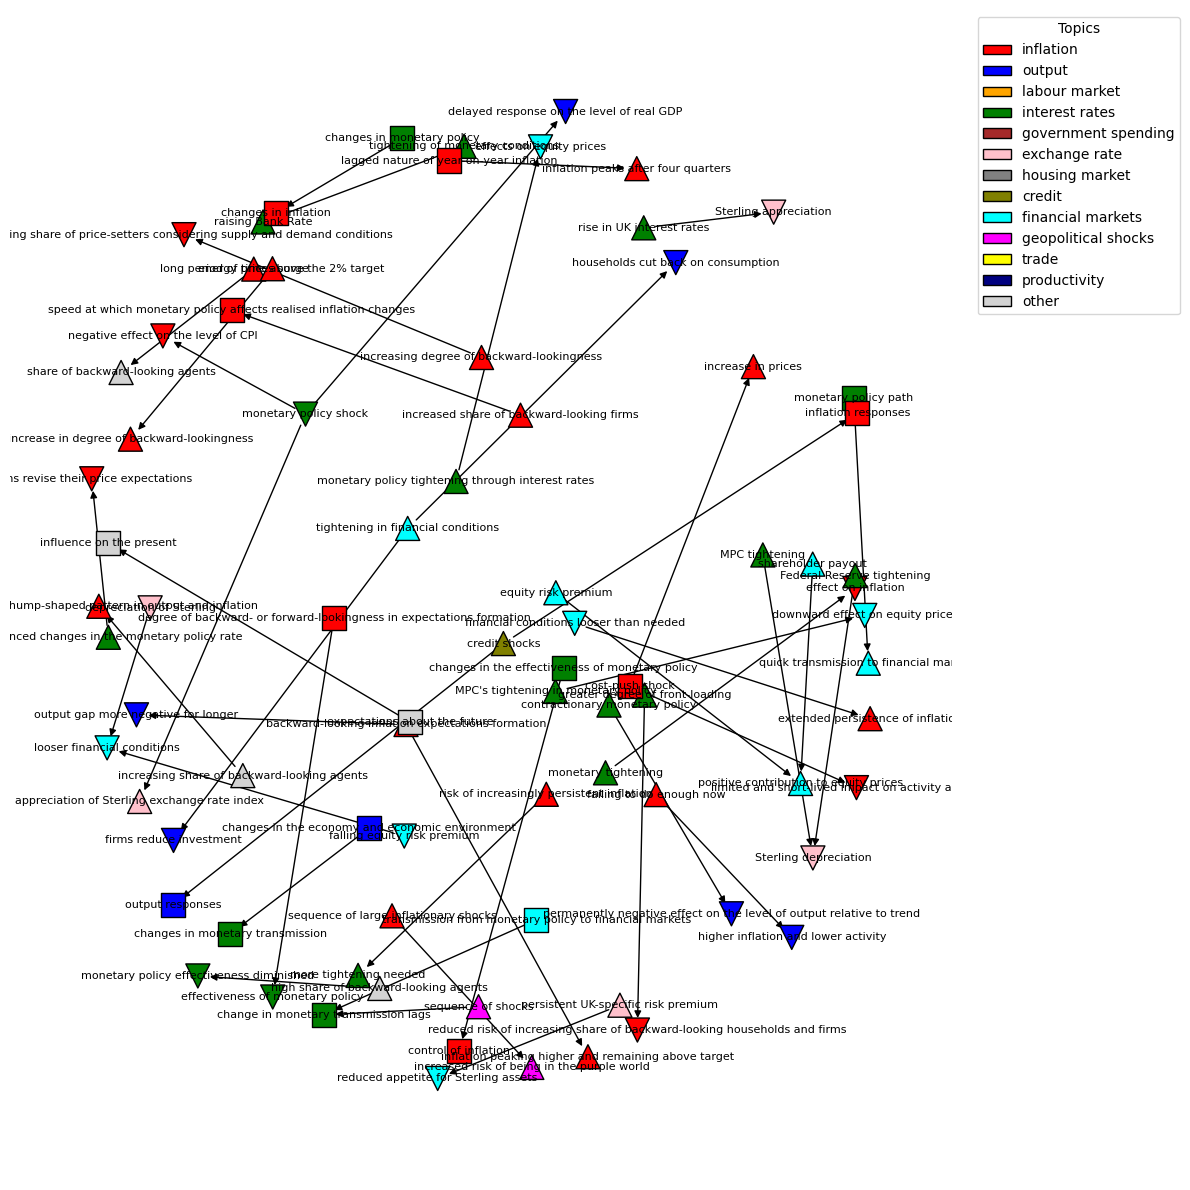

In [ ]:
plot_entity_graph(completed_entities_df[completed_entities_df['speech_id'] == 16653])

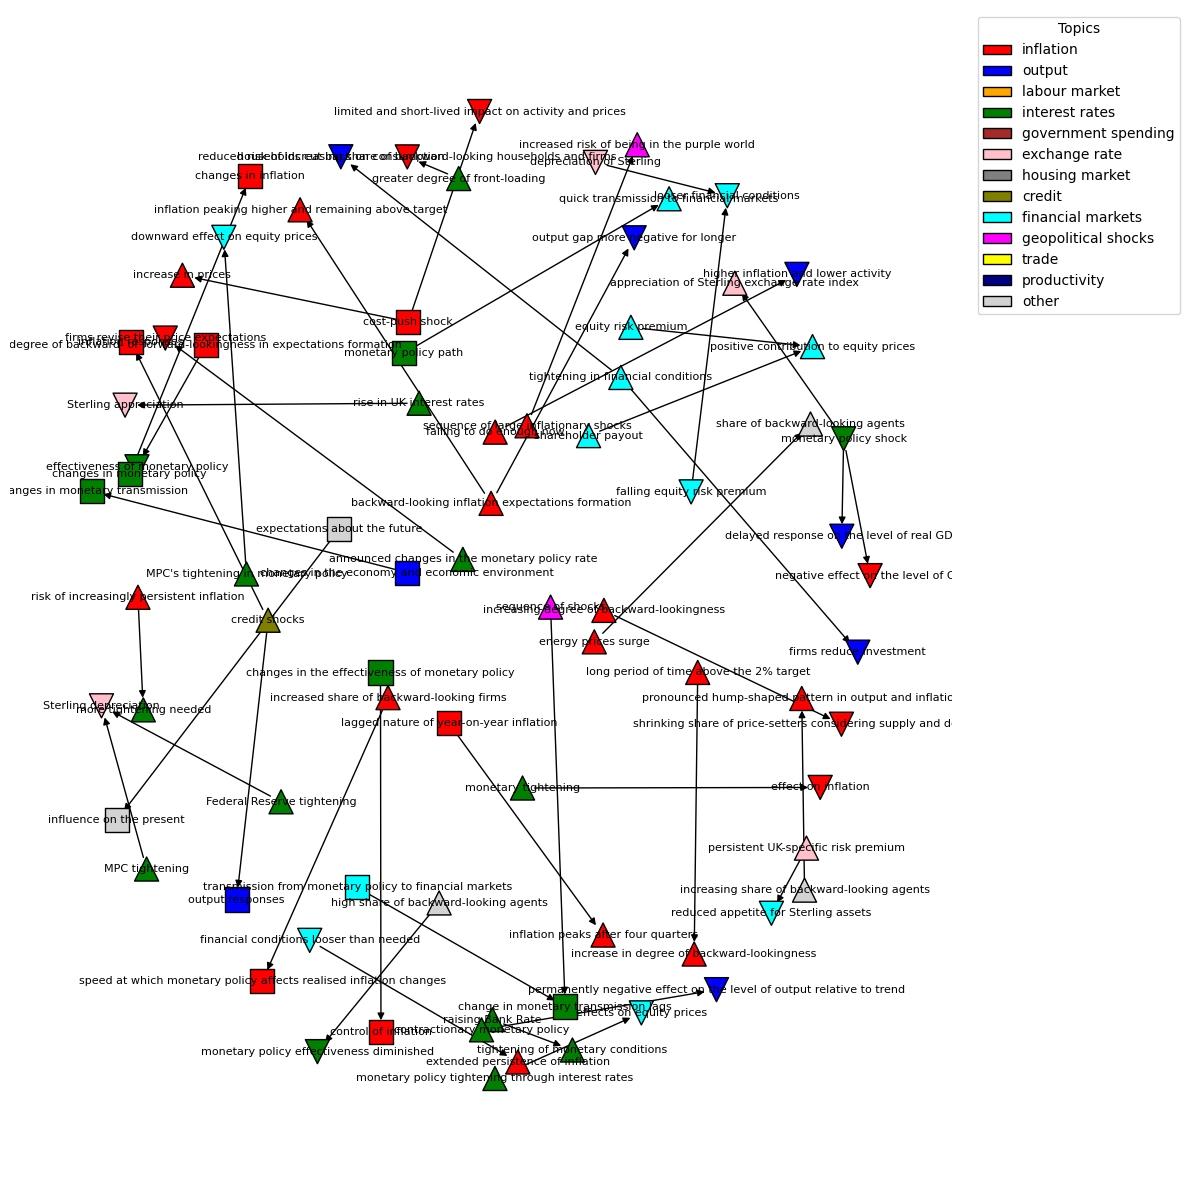

In [ ]:
# For a specific speech
speech_df = merged_entities_df[merged_entities_df['speech_id'] == 16653]
plot_entity_graph(speech_df)

In [ ]:
completed_entities_df[completed_entities_df['speech_id']==16653]

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,entity_effect,topic_effect,classification_effect
180,changes in monetary policy,changes in inflation,Changes in monetary policy take 18 to 24 month...,"In the central banking world, 18 to 24 months ...",18 to 24 months,NaN,over that timeframe,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_0,changes in monetary policy,interest rates,normal,changes in inflation,inflation,normal
181,changes in the economy and economic environment,changes in monetary transmission,Monetary transmission changes when the economy...,Monetary transmission will change when the eco...,NaN,NaN,NaN,FUTURE,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_1,changes in the economy and economic environment,output,normal,changes in monetary transmission,interest rates,normal
182,raising Bank Rate,tightening of monetary conditions,Raising Bank Rate tightens monetary conditions.,"Over the last year and a half, monetary condit...",390 basis points,NaN,over a short period of time,PAST,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_2,raising Bank Rate,interest rates,higher,tightening of monetary conditions,interest rates,higher
183,tightening in financial conditions,households cut back on consumption,A tightening in financial conditions leads hou...,"But to start the transmission process, a tight...",NaN,should,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_3,tightening in financial conditions,financial markets,higher,households cut back on consumption,output,lower
184,tightening in financial conditions,firms reduce investment,A tightening in financial conditions leads fir...,"Firms may reduce investment, both in response ...",NaN,may,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_4,tightening in financial conditions,financial markets,higher,firms reduce investment,output,lower
185,expectations about the future,influence on the present,Expectations about the future can influence th...,An often underappreciated feature of macroecon...,NaN,can,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_5,expectations about the future,other,normal,influence on the present,other,normal
186,MPC's tightening in monetary policy,downward effect on equity prices,MPC's tightening in monetary policy has a down...,The MPCs tightening in monetary policy has had...,NaN,NaN,over the last twelve months,PAST,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_6,MPC's tightening in monetary policy,interest rates,higher,downward effect on equity prices,financial markets,lower
187,shareholder payout,positive contribution to equity prices,Shareholder payout has made a positive contrib...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_7,shareholder payout,financial markets,higher,positive contribution to equity prices,financial markets,higher
188,equity risk premium,positive contribution to equity prices,Equity risk premium has made a positive contri...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_8,equity risk premium,financial markets,higher,positive contribution to equity prices,financial markets,higher
189,monetary policy tightening through interest rates,effects on equity prices,Monetary policy tightening through interest ra...,These have outweighed the effects of monetary ...,NaN,NaN,NaN,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_9,monetary policy tightening through interest rates,interest rates,

In [ ]:
entity_classifications_df['topic'].value_counts()

topic
inflation              200
interest rates         121
financial markets       84
output                  72
other                   43
government spending     25
labour market           22
geopolitical shocks     20
exchange rate           15
credit                  12
trade                    6
productivity             4
housing market           1
Name: count, dtype: int64

In [ ]:
entity_classifications_df[entity_classifications_df['topic']=='inflation']

,entity,topic,classification,document_reference,custom_id,speech_id,request_idx,speech_narrative_id,entity_type,entity_speech_narrative_id
1,inflationary expectations dynamic,inflation,higher,NaN,speech_16649_narr_16649_0_effect_0,16649,0,16649_0,effect,inflationary expectations dynamic|16649_0
3,purchasing power,inflation,lower,NaN,speech_16649_narr_16649_1_effect_1,16649,1,16649_1,effect,purchasing power|16649_1
4,current inflation,inflation,normal,NaN,speech_16649_narr_16649_2_cause_2,16649,2,16649_2,cause,current inflation|16649_2
5,future price inflation,inflation,higher,NaN,speech_16649_narr_16649_2_effect_2,16649,2,16649_2,effect,future price inflation|16649_2
6,price realisations,inflation,normal,NaN,speech_16649_narr_16649_3_cause_3,16649,3,16649_3,cause,price realisations|16649_3
...,...,...,...,...,...,...,...,...,...,...
583,ETS,inflation,higher,NaN,speech_16655_narr_16655_38_cause_287,16655,287,16655_38,cause,ETS|16655_38
584,higher inflation volatility,inflation,higher,NaN,speech_16655_narr_16655_38_effect_287,16655,287,16655_38,effect,higher inflation volatility|16655_38
596,reduction in relative prices of green goods,inflation,lower,NaN,speech_16655_narr_16655_44_effect_293,16655,293,16655_44,effect,reduction in relative prices of green goods|16...
609,policy-related uncertainty shocks,inflation,higher,NaN,speech_16655_narr_16655_51_cause_300,16655,300,16655_51,cause,policy-related uncertainty shocks|16655_51


In [ ]:
df_original_speech = pd.read_csv('../Data/Speeches/all_cb_speeches.csv', sep='\t')

In [ ]:
print("\n".join(df_original_speech[df_original_speech['speech_id']==16653]['text'].values[0].split('.')))

Bank of England Page 1 Expectations, lags, and the transmission of monetary policy - speech by Catherine L
 Mann Given at the Resolution Foundation 23 February 2023 Bank of England Page 2 Speech 1
 Introduction Economists often reference the long and variable lags of monetary policy, first introduced by Milton Friedman in 1961
 In the central banking world, 18 to 24 months is often quoted as how long it takes for changes in monetary policy to feed through to inflation, even as certainly this effect accumulates over that timeframe
 Although this has by now become a sort of folk wisdom, the economic and policy environment over the past few years has prompted me to re-examine these long and variable lags
 As Ive noted in numerous previous speeches1, the speed and magnitude of monetary transmission depends on the underlying structure of the economy, shocks the economy faces, and on the behaviour of financial markets, firms and households
 Monetary transmission will change when the economy 